<span style="font-size:8pt">*ÉTS Montréal, GPA671 : Introduction à l’intelligence artificielle. Date : le 23/10/21. Auteur : Jérôme Rony. Version : 1.2*</span>

# Laboratoire 2 : Classificateurs statistiques et SVM

## Exercise 1 : SVM linéaire à marge souple

Dans cet exercice, le but est d’implémenter un SVM linéaire à marge souple. Afin de pouvoir visualiser les frontières de décision, les données seront dans un espace à 2 dimensions pour cet exercise.

### Rappels de cours

Dans un SVM à marge souple, on cherche à maximiser la marge tout en minimisant les variables ressorts $\xi_i$, ce qui correspond au problème suivant :
\begin{equation}
\begin{aligned}
\underset{{\bf w}, b, \xi}{\text{minimize}}&& \frac{1}{2} {\bf w}^\top {\bf w} &+ C\sum\limits_{n=1}^{N}\xi_n\\
\text{subject to}&& \quad y_n({\bf w}^\top {\bf x}_n + b) & \geq 1 - \zeta_i  &n = 1, \dots, N\\
&& \xi_n & \geq 0 &n=1, \dots, N
\end{aligned}
\end{equation}

Avec C qui est un hyper-paramètre qui contrôle le compromis entre les deux objectifs de l’entrainement. Ce problème d’optimisation peut être reformulé en un problème équivalent :
\begin{equation}
\underset{{\bf w}, b}{\text{minimize}} \quad \frac{1}{2} {\bf w}^\top {\bf w} + C\sum\limits_{n=1}^{N}\max(0, 1 - y_n({\bf w}^\top {\bf x}_n + b))
\end{equation}


### Questions  (30 pts)

**Il est fortement conseiller de faire des fonctions pour chacune des étapes suivantes car il vous sera demandé refaire certaines étapes plusieurs fois dans les prochaines questions.**
1. Dans un premier temps, nous allons générer des données synthétiques que l’on peut presque séparer linéairement, c’est-à-dire avec du chevauchement, à l’aide du code suivant :
```python
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_clusters_per_class=1, random_state=42, shift=1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
```
Afficher ces données à l’aide de la fonction `scatter` de Matplotlib avec une couleur différente pour chaque classe. Commentez sur la distribution des données. (5 pts)

2. effectuez l'entrainement pour c = 1 et T = 1000. Utilisez le modèle SVC(kernel='linear',random_state=42) de la bibliothèque logicielle sklearn. affichez la frontière de décision et le taux d'exactitude. En s’inspirant de [la documentation de scikit-learn](https://scikit-learn.org/stable/auto_examples/svm/plot_linearsvc_support_vectors.html#sphx-glr-auto-examples-svm-plot-linearsvc-support-vectors-py), afficher la frontière de décision, les marges et vecteurs de supports par-dessus les données d’entrainement. N'utilisez pas de fonctions pour directement tracer cette courbe(faites le manuellement). (5 pts)

3. À l’aide des exemples de validation pour obtenir le taux d’exactitude, trouver les meilleurs hyper-paramètres en essayant les valeurs C  {0.005, 0.01, 0.1, 1, 10, 50, 100} et T  \{1, 10, 20, 50, 100, 200, 500,1000,2000,5000\} ( le nombre d'itération) .Éffectuez une recherche en grille de ces paramètres. Afficher un graphique de type «heat map» résumant les performances obtenues pour chaque combinaison de c et T . Expliquez l'impact de chaque hyper-paramètre. (5 pts)

4. À l'aide des données de test, utilisez la combinaison de C et T donnant les meilleurs performances et faites une inférence. Expliquez vos observations.(5 pts)

5. Effectuez ensuite une validation croisée avec k=5 pour toutes les recherches en grilles précédentes(N'utilisez pas de bibliothèques). Affichez le taux d'exactitude moyen pour chaque combinaison de T et de C à l'aide d'un graphique de type «heatmap». Calculez le temps d'entrainement pour chaque combinaison. Pourquoi est-il intéressant de faire une validation croisée, en général? Que remarquez-vous au niveau du temps d'entrainement en fonction des hyper paramètres, en général? Commentez et expliquez ce comportement. (5 pts)

6. Affichez  la frontière de décision pour T =5000 et C =  {0.005, 0.01, 0.1, 1, 10, 50, 100,1000}. Que remarquez vous? Quelles conclusions pouvez vous tirer quant au temps d'entrainement en fonction de C et expliquez ce phénomène? (5 pts)


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_clusters_per_class=1, random_state=42, shift=1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

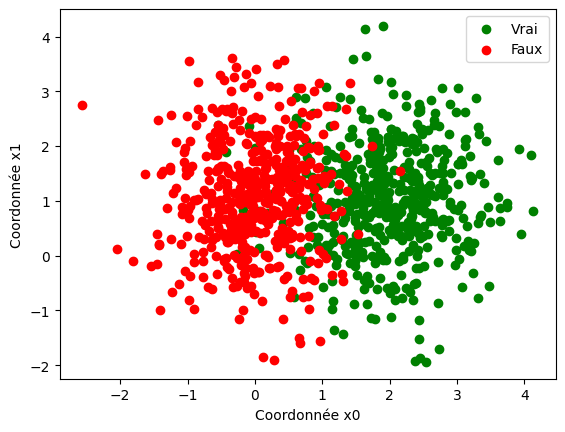

In [ ]:
#Q1 : Afficher ces données à l’aide de la fonction scatter de Matplotlib avec une couleur différente pour chaque classe.
#     Commentez sur la distribution des données. (5 pts)
import matplotlib.pyplot as plt
import numpy as np

# print('donnée X : ', X)
# print('donnée Y : ', y)

def affichage_data(data_X, data_y):
  mask_vrai = data_y.flatten().T == 1
  mask_faux = data_y.flatten().T == 0

  x_vrai = data_X[mask_vrai]
  x_faux = data_X[mask_faux]

  plt.scatter(x_vrai[:,0], x_vrai[:,1], color= 'green', label='Vrai')
  plt.scatter(x_faux[:,0], x_faux[:,1], color= 'red', label='Faux')
  plt.xlabel('Coordonnée x0')
  plt.ylabel('Coordonnée x1')
  plt.legend()

affichage_data(X,y)

W est : [ 2.17841235 -0.17052959]
Biais est : -1.8023194622384895
exactitute : 0.92


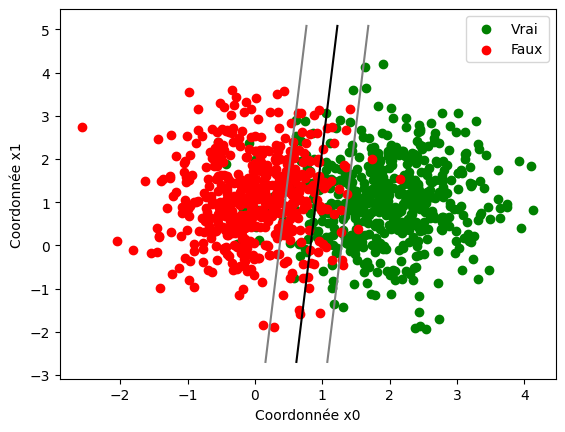

In [ ]:
#Q2 effectuez l'entrainement pour c = 1 et T = 1000. Utilisez le modèle SVC(kernel='linear',random_state=42) de la bibliothèque logicielle sklearn.
#   affichez la frontière de décision et le taux d'exactitude. En s’inspirant de la documentation de scikit-learn, afficher la frontière de décision,
#   les marges et vecteurs de supports par-dessus les données d’entrainement. N'utilisez pas de fonctions pour directement tracer cette courbe(faites le manuellement). (5 pts)

from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

C = 1 #Paramètre de régulation
T = 1000 #Nb max d'itération

LSVC = LinearSVC(C=C, loss="hinge",random_state=42, max_iter=T).fit(X_train,y_train)

w = LSVC.coef_[0]
b = LSVC.intercept_[0]
y_resultat = LSVC.predict(X_val)

print("W est :", w)
print("Biais est :",b)

def frontiere_decision_x0(x):
  #definir le min et le max en x et faire une ligne de points entre les deux
  x0_front_val = np.linspace(min(x[:,0]), max(x[:,0]),100)
  return x0_front_val

def frontiere_decision_x1(x0,w,b):
  #definir le valeurs de la frontière de décision selon les x1 défini ci-haut
  x1_front_val = []
  for x in x0:
    x1_front_val.append((- w[0]*x - b)/w[1])
  return np.array(x1_front_val)

def marge_decision_positive(x1,w,b):
  #definir les valeurs de la marge positive
  x0_marge_pos_val = []
  for x in x1:
    x0_marge_pos_val.append((- w[1]*x - b + 1)/w[0])
  return np.array(x0_marge_pos_val)

def marge_decision_negative(x1,w,b):
  #definir les valeurs de la marge positive
  x0_marge_neg_val = []
  for x in x1:
    x0_marge_neg_val.append((- w[1]*x - b - 1)/w[0])
  return np.array(x0_marge_neg_val)

def affichage_decision(X,y,w,b):
  #definition de la frontière et des marges
  front_x0 = frontiere_decision_x0(X)
  front_x1 = frontiere_decision_x1(front_x0,w,b)

  #creation d'un masque de x1
  val_min = min(X[:,1])
  val_max = max(X[:,1])
  masque = (front_x1>=(val_min-1)) & (front_x1<=(val_max+1))

  #application de la masque
  front_x0_masque = front_x0[masque]
  front_x1_masque = front_x1[masque]
  marge_pos = marge_decision_positive(front_x1_masque,w,b)
  marge_neg = marge_decision_negative(front_x1_masque,w,b)

  #ajout de la frontière de décision
  plt.plot(front_x0_masque,front_x1_masque,color='black')
  #ajout des marges
  plt.plot(marge_pos,front_x1_masque,color='grey')
  plt.plot(marge_neg,front_x1_masque,color='grey')

def affichage_data_decision(X,y,w,b):
  #afficher les datas
  affichage_data(X,y)
  #afficher frontière
  affichage_decision(X,y,w,b)

def taux_exactitude(y_pred,y_train):
  #matrice de confusion
  matrice = confusion_matrix(y_train, y_pred)
  #pour la meilleur compréhension
  tp = matrice[1,1]
  tn = matrice[0,0]
  total = len(y_train)
  return (tp+tn)/total


affichage_data_decision(X,y,w,b)
print("exactitute :", taux_exactitude(y_resultat,y_val))

[[0.905 0.91  0.909 0.909 0.909 0.909 0.909 0.909 0.909 0.909]
 [0.912 0.912 0.912 0.912 0.912 0.912 0.912 0.912 0.912 0.912]
 [0.863 0.911 0.911 0.911 0.911 0.911 0.911 0.911 0.911 0.911]
 [0.754 0.913 0.912 0.913 0.914 0.914 0.914 0.914 0.914 0.914]
 [0.752 0.792 0.849 0.91  0.914 0.912 0.914 0.915 0.914 0.915]
 [0.752 0.771 0.787 0.837 0.878 0.899 0.912 0.914 0.915 0.914]
 [0.752 0.771 0.787 0.895 0.899 0.897 0.914 0.912 0.913 0.914]]


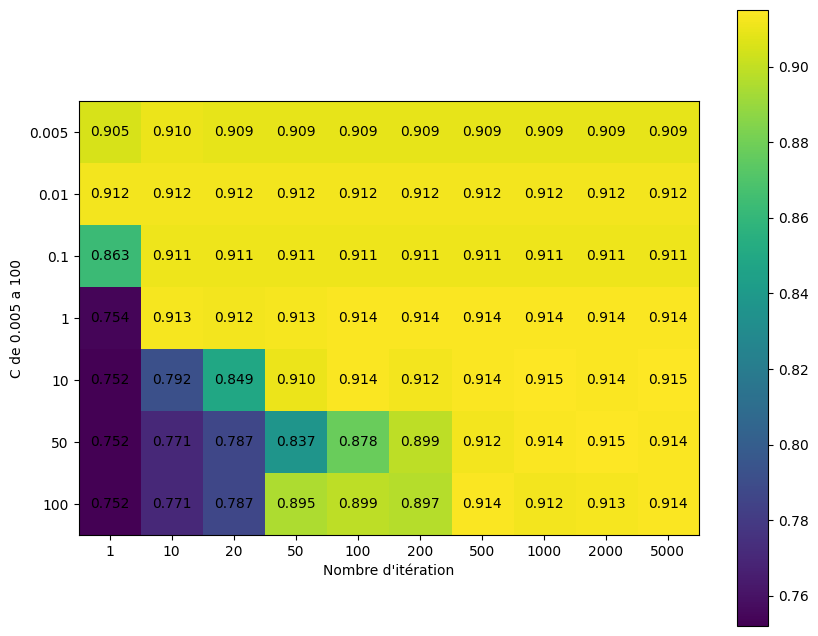

le meilleur resultat est :  0.915
Pour les valeurs de C et T suivante :  [{'C': 10, 'T': 1000}, {'C': 10, 'T': 5000}, {'C': 50, 'T': 2000}]


In [ ]:
#Q3 À l’aide des exemples de validation pour obtenir le taux d’exactitude, trouver les meilleurs hyper-paramètres en essayant les valeurs C {0.005, 0.01, 0.1, 1, 10, 50, 100} et
#   T {1, 10, 20, 50, 100, 200, 500,1000,2000,5000} ( le nombre d'itération) .Éffectuez une recherche en grille de ces paramètres. Afficher un graphique de type «heat map» résumant
#   les performances obtenues pour chaque combinaison de c et T . Expliquez l'impact de chaque hyper-paramètre. (5 pts)

import warnings
from sklearn.exceptions import ConvergenceWarning

# Désactiver les avertissements de convergence - Ligne généré grace a chatGPT
warnings.filterwarnings("ignore", category=ConvergenceWarning)

C = [0.005, 0.01, 0.1, 1, 10, 50, 100]
T = [1, 10, 20, 50, 100, 200, 500,1000,2000,5000]

#nb de combinaison => 7 x 10 = 70
exact = np.full((len(C),len(T)),-1.0)

for i, c in enumerate(C):
  for j,t in enumerate(T):
    LSVC = LinearSVC(C=c, loss="hinge",random_state=42, max_iter=t).fit(X,y)
    w = LSVC.coef_[0]
    b = LSVC.intercept_[0]
    y_resultat = LSVC.predict(X)
    exact[i][j] = taux_exactitude(y_resultat,y)

print(exact)

def meilleur_resultat_C_T(data,C,T):
  meilleur = np.max(data)
  indice_max = np.where(data == meilleur)
  coordo = []
  for i in range(len(indice_max[0])):
    ligne = indice_max[0][i]
    colonne = indice_max[1][i]
    coordo.append({'C': C[ligne], 'T': T[colonne]})
  return meilleur, coordo

def affichage_heatmap(data,xticks,yticks):
  plt.figure(figsize=(10, 8))  # Taille de la figure
  plt.imshow(data,cmap='viridis')
  plt.colorbar()
  plt.xticks(np.arange(len(xticks)),xticks)
  plt.yticks(np.arange(len(yticks)),yticks)
  plt.xlabel("Nombre d'itération")
  plt.ylabel("C de 0.005 a 100")
  for i in range(data.shape[0]):  # Parcours des lignes
    for j in range(data.shape[1]):  # Parcours des colonnes
      plt.text(j, i, f"{data[i, j]:.3f}", ha='center', va='center', color='white'
               if data[i, j] < np.max(data) / 2 else 'black')
  plt.show()


affichage_heatmap(exact,T,C)

best, valeurs = meilleur_resultat_C_T(exact,C,T)
print("le meilleur resultat est : ", best)
print("Pour les valeurs de C et T suivante : ", valeurs)

# On voit que l'impact des deux paramètre n'est pas linéaire et qu'il y a plus d'une facon pour optenir des résultats équivalent.
# C a un impact direct sur l'épaisseur de la marge et que celle si regule la sensibilité, plus C est élévé, plus la marge est sensible et donc plus il est sensible au points mal classés.
# T est quand a lui le maximum d'iteration que feras l'apprentissage. Il est possible qu'avec un petit T, le SVM ne diverge pas vers une solution optimal.


In [ ]:
#Q4 À l'aide des données de test, utilisez la combinaison de C et T donnant les meilleurs performances et faites une inférence. Expliquez vos observations.(5 pts)

# Dans le case de la situation présente, les meilleurs résultat son a 0.915 avec C = 10 et T = 1000 ou 5000 ainsique que pout C = 50 avec T = 2000

# On va utiliser X_Train et y_Train pour l'entrainement et X_test et y_test pour tester
 #Entrainement sur les données :
LSVC = LinearSVC(C=10, loss="hinge",random_state=42, max_iter=1000)
LSVC.fit(X_train,y_train)
w = LSVC.coef_[0]
b = LSVC.intercept_[0]

#avec valeur de validation
y_resultat = LSVC.predict(X_val)
print("exactitude :", taux_exactitude(y_resultat,y_val))

#avec valeur de test
y_resultat = LSVC.predict(X_test)
print("exactitude :", taux_exactitude(y_resultat,y_test))

# On obtient des résultats similaire au meilleur résultat, et même une exactitude plus haute si on utiliser les valeurs de validations

exactitude : 0.925
exactitude : 0.91


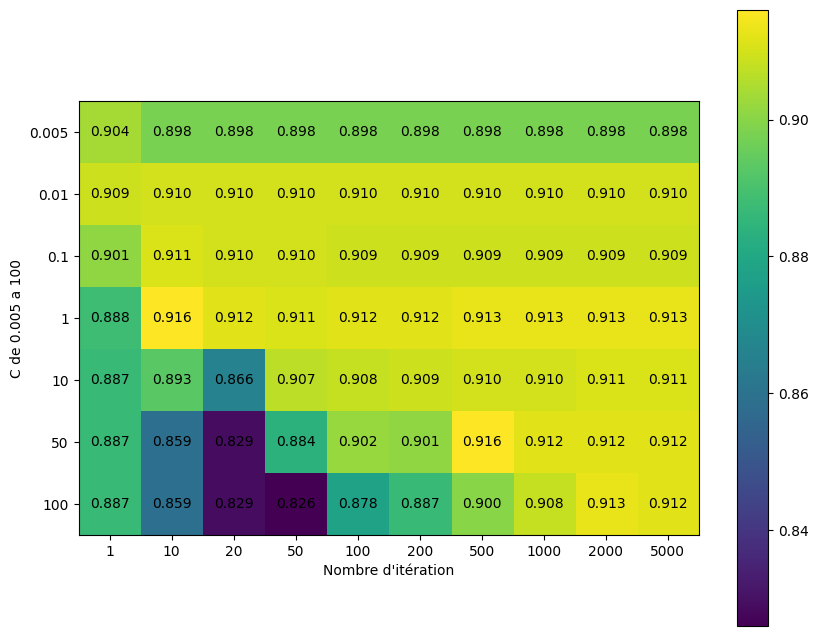

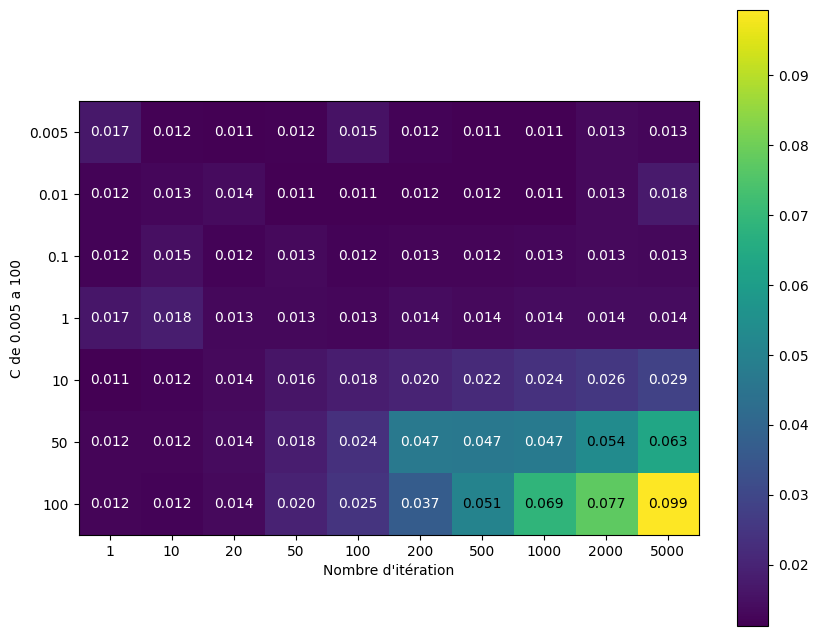

In [ ]:
#Q5 Effectuez ensuite une validation croisée avec k=5 pour toutes les recherches en grilles précédentes(N'utilisez pas de bibliothèques).
#   Affichez le taux d'exactitude moyen pour chaque combinaison de T et de C à l'aide d'un graphique de type «heatmap». Calculez le temps d'entrainement pour chaque combinaison.
#   Pourquoi est-il intéressant de faire une validation croisée, en général? Que remarquez-vous au niveau du temps d'entrainement en fonction des hyper paramètres, en général?
#   Commentez et expliquez ce comportement. (5 pts)

import numpy as np
import time

# C=0.5
# T=100
K=5


def validation_croiser(X,Y,K,C,T):

  taille = len(X)//K
  exactitude_kFold = []
  debut_temps = time.time()

  for i in range(K):
    #definir les indices de debut et la fin de l'échantillon utiliser
    debut = i*taille
    fin = debut + taille
    #valeur de test
    X_test = X[debut:fin]
    Y_test = Y[debut:fin]
    #valeur d'entrainement
    X_train = np.concatenate((X[:debut], X[fin:])) #avant le debut et apres la fin
    Y_train = np.concatenate((Y[:debut],Y[fin:]))

    #effectuer l'entrainement sur cette base de donnée
    LSVC = LinearSVC(C=C, loss="hinge",random_state=42, max_iter=T).fit(X_train,Y_train)
    w = LSVC.coef_[0]
    b = LSVC.intercept_[0]
    #test les valeurs
    y_resultat = LSVC.predict(X_test)
    exactitude_kFold.append(taux_exactitude(y_resultat,Y_test))

  fin_temps = time.time()
  temps_total = fin_temps - debut_temps
  return(exactitude_kFold,temps_total)


exact_moyen = np.full((len(C),len(T)),-1.0)
duree_temps = np.full((len(C),len(T)),-1.0)
for i, c in enumerate(C):
  for j,t in enumerate(T):
    accuracy_temporaire, duree_temporaire = validation_croiser(X,y,K,c,t)
    exact_moyen[i][j] = np.mean(accuracy_temporaire)
    duree_temps[i][j] = duree_temporaire

# print(exact_moyen)
# print(duree_temps)

affichage_heatmap(exact_moyen,T,C)
affichage_heatmap(duree_temps,T,C)

# Le meilleur résultat est a 0.916 avec les valeur de C = 50 et T = 500 avec un temps de 0.09999 ms
# Nous remarquons bien a l'aide du tableau si bas que, en plus d'être le plus efficace, il respecte un temps d'entrainement similaire a d'autre combinaison, excluant bien sur avec le C et le T les plus elever.


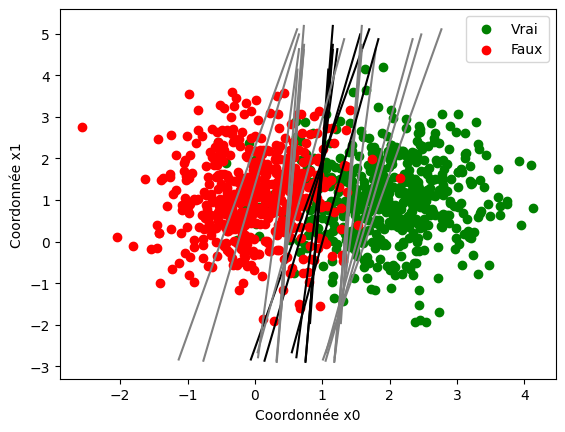

In [ ]:
#Q6 Affichez la frontière de décision pour T =5000 et C = {0.005, 0.01, 0.1, 1, 10, 50, 100,1000}. Que remarquez vous?
#   Quelles conclusions pouvez vous tirer quant au temps d'entrainement en fonction de C et expliquez ce phénomène? (5 pts)

affichage_data(X,y)
C = [0.005, 0.01, 0.1, 1, 10, 50, 100,1000]
T = 5000

for c in C:

  LSVC = LinearSVC(C=c, loss="hinge",random_state=42, max_iter=T).fit(X,y)
  w = LSVC.coef_[0]
  b = LSVC.intercept_[0]
  affichage_decision(X,y,w,b)

# Plus la valeur de C est petite et plusle modèle tolère des erreurs de classifications. Il est possible, comme dans le cas présent
# qu'une petite valeur entraine un sous apprentissage. (On le vois particulièrement pour un T élever)
# Plus la marge est large cela n'indique pas nécéssairement qu'il s'agit de la solution optimal. Il faut trouver un juste
# milieu qui permets un marge assez petite pour ne pas être underfitted et ce avec un nombre d'itération assez elever pour permetre
# un entrainement suffisant.


## Exercise 2 : SVM à noyau(20 pts)

### Rappels de cours

Dans un SVM à noyau, les vecteurs ${\bf x}_n$ sont projetés dans un nouvel espace par la fonction $\phi$ pour obtenir ${\bf z}_n = \phi({\bf x}_n)$. Cependant, ce nouveau vecteur peut possiblement avoir une dimension infinie (ce qui est le cas pour un noyau Gaussien). On ne veut / peut donc pas calculer explicitement ces vecteurs. Pour maximiser la marge avec les contraintes comme précédemment, on ne peut donc plus résoudre le problème primal ; on doit passe donc au *dual*. On résout alors le problème suivant :
\begin{equation}
\begin{aligned}
\underset{\alpha}{\text{maximize}}&& \sum\limits_{n=1}^{N} \alpha_n &- \frac{1}{2}\sum\limits_{n=1}^{N}\sum\limits_{m=1}^{N}\alpha_n\alpha_m y_n y_m K({\bf x}_n, {\bf x}_m)\\
\text{subject to}&& 0 \leq \alpha_n &\leq C \quad n = 1, \dots, N\\
&& \sum\limits_{n=1}^N \alpha_n y_n &= 0
\end{aligned}
\end{equation}

Ici, $\alpha\in\mathbb{R}_+^N$ est un vecteur qui donne un "poids" à chaque donnée d’entrainement, $K$ est la fonction noyau et C est l’hyper-paramètre qui contrôle le compromis entre les deux objectifs de l’entrainement. Sous certaines conditions, on peut montrer que $K({\bf x}_n, {\bf x}_m) = {\bf z}_n^\top {\bf z}_m = \phi({\bf x}_n)^\top \phi({\bf x}_m)$. C’est-à-dire que $K$ permet d’exprimer la ressemblance entre deux vecteurs dans un espace transformé (possiblement à dimension infinie), sans jamais explicitement transformer les vecteurs d’entrées ${\bf x}_n$.

Dans cet exercice, on va utiliser le noyau Gaussien, qui est le plus courant, définit par :
\begin{equation}
K({\bf x}_n, {\bf x}_m) = \exp(-\gamma ||{\bf x}_n - {\bf x}_m||^2)
\end{equation}
Ici, $\gamma$ correspond à l’inverse de deux fois la déviation standard au carré $\gamma = \frac{1}{2\sigma^2}$. Son choix est critique pour la performance ; une bonne approximation (utilisée par défaut dans scikit-learn) est : $$\gamma = \frac{1}{\text{entrées} \cdot \mathrm{Var}(X)}$$



Une fois le problème ci-dessus résolu, on obtient un vecteur $\alpha\in\mathbb{R}_+^N$. Chaque composante de ce vecteur est positive ou nulle et les données ${\bf x}_n$ pour lesquelles $\alpha_n > 0$ sont appelés des **vecteurs de support**. On peut alors effectuer une prediction pour un nouveau vecteur ${\bf x}$:
\begin{equation}
y_{\text{pred}} = \sum\limits_{n=1}^{N}\alpha_n y_n K({\bf x}, {\bf x}_n) + b
\end{equation}
Où $b$ est le biais. On peut remarquer que le biais n’apparait pas dans le problème résolu précédemment. Pour le trouver, on utilise l’équation suivante :
\begin{equation}
b = \frac{1}{|\mathcal{S}|}\sum\limits_{n\in\mathcal{S}}\left(y_n - \sum\limits_{m=1}^N \alpha_m y_m K({\bf x}_n, {\bf x}_m)\right)
\end{equation}
où $\mathcal{S} = \{n : \alpha_n \neq 0, n=1,\dots,N\}$ est l’ensemble des indices des vecteurs de support.

### Questions:

1. Effectuez les points 1 à 6 de l'exercise 1 mais avec les données suivantes:      (10 pts)
```python
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)   
```
commentez sur les différences pour chaques étapes.

2. Effectuez les points 1 à 6 de la l'excercise 1 mais avec les données suivantes et le modèle suivant:     (10 pts)
```python
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
SVC(kernel='rbf' ,random_state=42)
```
commentez sur les différences pour chaques étapes.

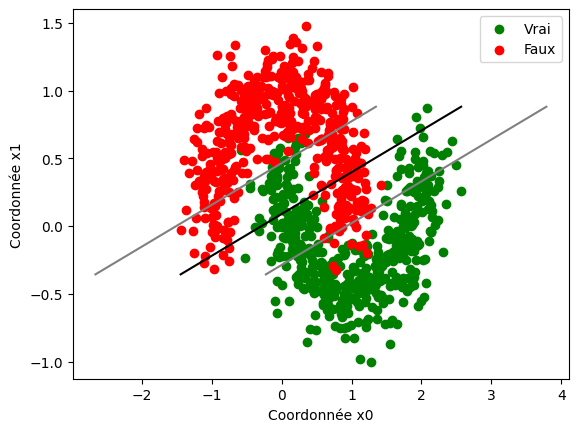

In [38]:
#Q1 Effectuez les points 1 à 6 de l'exercise 1 mais avec les données suivantes: (10 pts)

from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

#   1 - Afficher ces données à l’aide de la fonction scatter de Matplotlib avec une couleur différente pour chaque classe. Commentez sur la distribution des données. (5 pts)

#
#   2 - effectuez l'entrainement pour c = 1 et T = 1000. Utilisez le modèle SVC(kernel='linear',random_state=42) de la bibliothèque logicielle sklearn. affichez la frontière de décision et le taux d'exactitude.
#       En s’inspirant de la documentation de scikit-learn, afficher la frontière de décision, les marges et vecteurs de supports par-dessus les données d’entrainement.
#       N'utilisez pas de fonctions pour directement tracer cette courbe(faites le manuellement). (5 pts)

C=1
T=1000

LSVC = LinearSVC(C=C, loss="hinge",random_state=42, max_iter=T).fit(X,y)

w = LSVC.coef_[0]
b = LSVC.intercept_[0]
y_resultat = LSVC.predict(X)

affichage_data_decision(X,y,w,b)


[[0.838 0.836 0.836 0.836 0.836 0.836 0.836 0.836 0.836 0.836]
 [0.854 0.845 0.845 0.845 0.845 0.845 0.845 0.845 0.845 0.845]
 [0.862 0.866 0.865 0.865 0.865 0.865 0.865 0.865 0.865 0.865]
 [0.818 0.868 0.864 0.866 0.867 0.866 0.866 0.866 0.866 0.866]
 [0.809 0.632 0.829 0.869 0.866 0.868 0.868 0.868 0.868 0.868]
 [0.809 0.853 0.85  0.761 0.862 0.855 0.866 0.863 0.867 0.866]
 [0.809 0.853 0.85  0.836 0.853 0.855 0.871 0.865 0.87  0.868]]


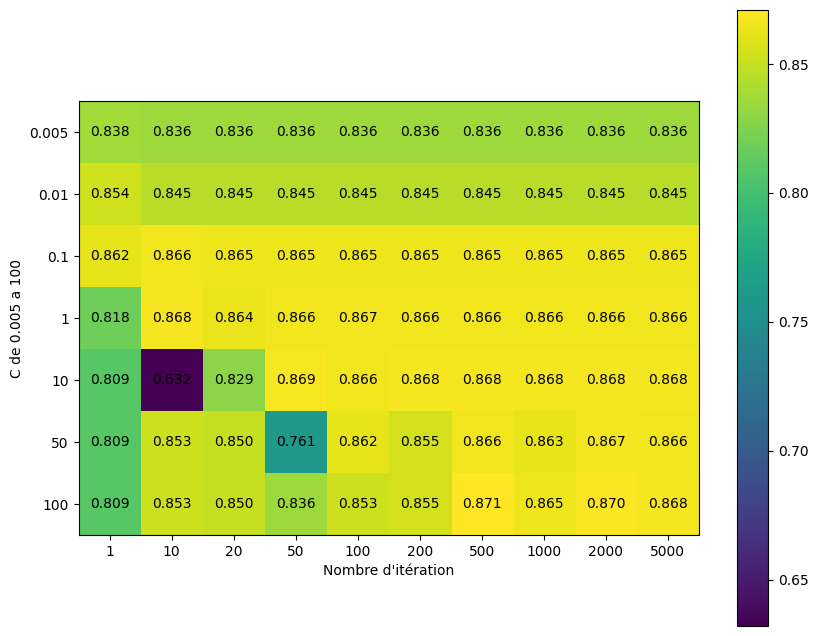

le meilleur resultat est :  0.871
Pour les valeurs de C et T suivante :  [{'C': 100, 'T': 500}]


In [39]:
#   3 - À l’aide des exemples de validation pour obtenir le taux d’exactitude, trouver les meilleurs hyper-paramètres en essayant les valeurs C {0.005, 0.01, 0.1, 1, 10, 50, 100} et
#       T {1, 10, 20, 50, 100, 200, 500,1000,2000,5000} ( le nombre d'itération) .Éffectuez une recherche en grille de ces paramètres.
#       Afficher un graphique de type «heat map» résumant les performances obtenues pour chaque combinaison de c et T . Expliquez l'impact de chaque hyper-paramètre. (5 pts)

import warnings
from sklearn.exceptions import ConvergenceWarning

# Désactiver les avertissements de convergence - Ligne généré grace a chatGPT
warnings.filterwarnings("ignore", category=ConvergenceWarning)

C = [0.005, 0.01, 0.1, 1, 10, 50, 100]
T = [1, 10, 20, 50, 100, 200, 500,1000,2000,5000]

#nb de combinaison => 7 x 10 = 70
exact = np.full((len(C),len(T)),-1.0)

for i, c in enumerate(C):
  for j,t in enumerate(T):
    LSVC = LinearSVC(C=c, loss="hinge",random_state=42, max_iter=t).fit(X,y)
    w = LSVC.coef_[0]
    b = LSVC.intercept_[0]
    y_resultat = LSVC.predict(X)
    exact[i][j] = taux_exactitude(y_resultat,y)

print(exact)

affichage_heatmap(exact,T,C)

best, valeurs = meilleur_resultat_C_T(exact,C,T)
print("le meilleur resultat est : ", best)
print("Pour les valeurs de C et T suivante : ", valeurs)

# dans le cadre de ses données, on vois bien que le niveau d'exactitude est moins élever du au fait qu'elles sont plus difficilement séparable de façons linéaire.
# Les meilleurs résultat ce situe dans les environs de 0.871 pour un C = 1 et un T = 500
# Pour les explications des hyper-paramètre, voir exercice 1 question 3

In [40]:
#   4 - À l'aide des données de test, utilisez la combinaison de C et T donnant les meilleurs performances et faites une inférence. Expliquez vos observations.(5 pts)
# Dans le case de la situation présente, les meilleurs résultat son a 0.871 avec C = 1 et T = 500 ainsi


#On sépare les données
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# On va utiliser X_Train et y_Train pour l'entrainement et X_test et y_test pour tester
 #Entrainement sur les données :
LSVC = LinearSVC(C=1, loss="hinge",random_state=42, max_iter=500)
LSVC.fit(X_train,y_train)
w = LSVC.coef_[0]
b = LSVC.intercept_[0]

#avec valeur de validation
y_resultat = LSVC.predict(X_val)
print("exactitude :", taux_exactitude(y_resultat,y_val))

# On obtient des résultats un peux inférieur au meilleur résultat en séparant les données. Comme elle sont difficilement séparable de facon linéaire, ceci peux expliqué
# la différence.

exactitude : 0.855


[[0.829 0.832 0.832 0.832 0.832 0.832 0.832 0.832 0.832 0.832]
 [0.846 0.842 0.842 0.842 0.842 0.842 0.842 0.842 0.842 0.842]
 [0.863 0.864 0.863 0.863 0.862 0.862 0.863 0.863 0.863 0.863]
 [0.745 0.861 0.867 0.863 0.863 0.863 0.863 0.863 0.863 0.863]
 [0.724 0.838 0.863 0.858 0.867 0.866 0.864 0.864 0.863 0.863]
 [0.724 0.801 0.834 0.783 0.84  0.863 0.861 0.868 0.865 0.866]
 [0.724 0.801 0.834 0.784 0.809 0.867 0.857 0.866 0.864 0.866]]
[[0.0172863  0.01219535 0.0118351  0.01251745 0.01182151 0.01241159
  0.01194811 0.01266217 0.01188374 0.01313114]
 [0.0137651  0.01982737 0.01281428 0.01538992 0.01308274 0.01289868
  0.01198292 0.01206136 0.01303267 0.01220751]
 [0.01612258 0.01188016 0.01237702 0.01177335 0.01167917 0.01166439
  0.01278734 0.01280832 0.01243949 0.01235819]
 [0.01159024 0.01252484 0.01264238 0.01270771 0.01287127 0.01322412
  0.01352739 0.01529717 0.01697874 0.01468658]
 [0.01160479 0.01474118 0.01433253 0.01697898 0.01725054 0.01821351
  0.01946545 0.02095008 0.0227

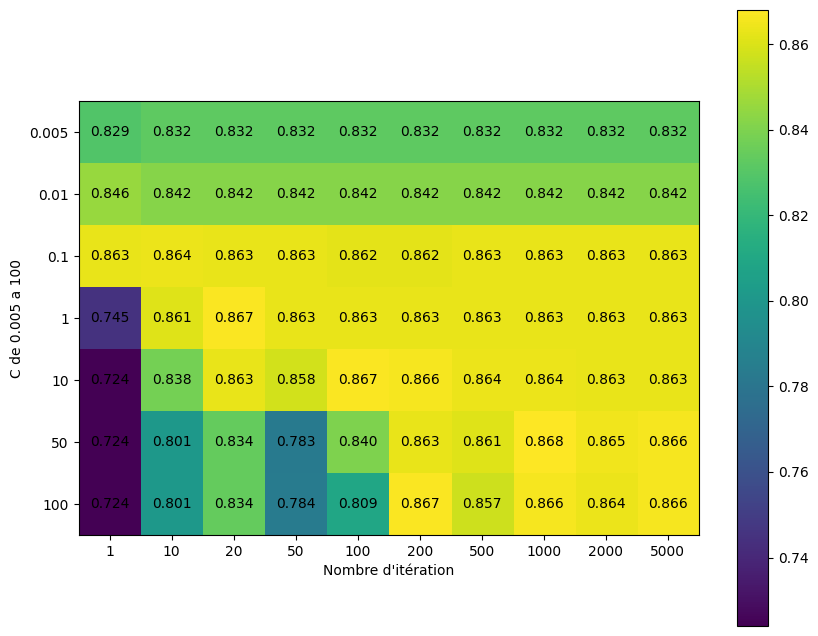

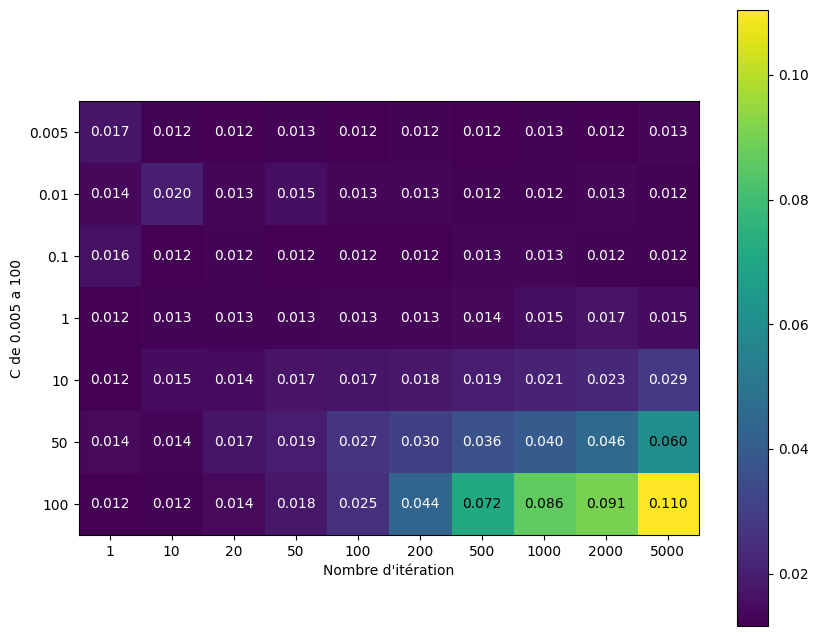

In [41]:
#   5 - Effectuez ensuite une validation croisée avec k=5 pour toutes les recherches en grilles précédentes(N'utilisez pas de bibliothèques).
#       Affichez le taux d'exactitude moyen pour chaque combinaison de T et de C à l'aide d'un graphique de type «heatmap». Calculez le temps d'entrainement pour chaque combinaison.
#       Pourquoi est-il intéressant de faire une validation croisée, en général? Que remarquez-vous au niveau du temps d'entrainement en fonction des hyper paramètres, en général?
#       Commentez et expliquez ce comportement. (5 pts)
K=5

exact_moyen = np.full((len(C),len(T)),-1.0)
duree_temps = np.full((len(C),len(T)),-1.0)
for i, c in enumerate(C):
  for j,t in enumerate(T):
    accuracy_temporaire, duree_temporaire = validation_croiser(X,y,K,c,t)
    exact_moyen[i][j] = np.mean(accuracy_temporaire)
    duree_temps[i][j] = duree_temporaire

print(exact_moyen)
print(duree_temps)

affichage_heatmap(exact_moyen,T,C)
affichage_heatmap(duree_temps,T,C)

# Le comportement ici est similaire au jeux de donnée de la question 1. Il est possible d'avoir un taux d'exactitude accepte sans que cela sois les valeurs de C et T les plus grande

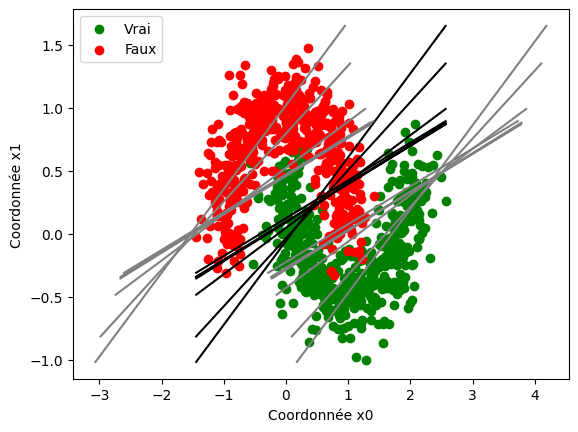

In [42]:
#   6 - Affichez la frontière de décision pour T =5000 et C = {0.005, 0.01, 0.1, 1, 10, 50, 100,1000}. Que remarquez vous? Quelles conclusions pouvez vous tirer quant au temps
#       d'entrainement en fonction de C et expliquez ce phénomène? (5 pts)

affichage_data(X,y)
C = [0.005, 0.01, 0.1, 1, 10, 50, 100,1000]
T = 5000

for c in C:

  LSVC = LinearSVC(C=c, loss="hinge",random_state=42, max_iter=T).fit(X,y)
  w = LSVC.coef_[0]
  b = LSVC.intercept_[0]
  affichage_decision(X,y,w,b)

# Comme dans le cas de la question 1, plus C est petit, plus la marge est grande, Ce
# Plus la valeur de C est petite et plusle modèle tolère des erreurs de classifications. Il est possible, comme dans le cas présent
# qu'une petite valeur entraine un sous apprentissage. (On le vois particulièrement pour un T élever)
# Plus la marge est large cela n'indique pas nécéssairement qu'il s'agit de la solution optimal. Il faut trouver un juste
# milieu qui permets un marge assez petite pour ne pas être underfitted et ce avec un nombre d'itération assez elever pour permetre
# un entrainement suffisant.

#On remaque aussi que, comme les données sont en croissant de lune, la marge a tendance a "tordre" lorsqu'on lui donne plus d'itération.

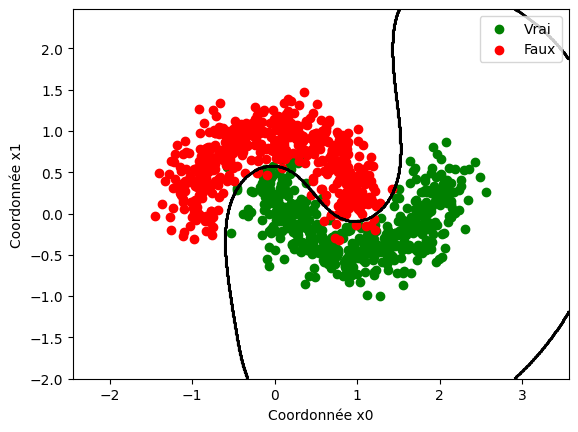

In [43]:
#Q2 Effectuez les points 1 à 6 de l'exercise 1 mais avec les données suivantes: (10 pts)
from sklearn.datasets import make_moons
from sklearn.svm import SVC
X_2, y_2 = make_moons(n_samples=1000, noise=0.2, random_state=42)

#   1 - Afficher ces données à l’aide de la fonction scatter de Matplotlib avec une couleur différente pour chaque classe. Commentez sur la distribution des données. (5 pts)

#
#   2 - effectuez l'entrainement pour c = 1 et T = 1000. Utilisez le modèle SVC(kernel='linear',random_state=42) de la bibliothèque logicielle sklearn. affichez la frontière de décision et le taux d'exactitude.
#       En s’inspirant de la documentation de scikit-learn, afficher la frontière de décision, les marges et vecteurs de supports par-dessus les données d’entrainement.
#       N'utilisez pas de fonctions pour directement tracer cette courbe(faites le manuellement). (5 pts)

C=1
T=1000

SVC_2 = SVC(C=C,kernel='rbf' ,random_state=42, max_iter=T)
SVC_2.fit(X_2,y_2)

# w = SVC.coef_[0]
# b = SVC.intercept_[0]
y_resultat = SVC_2.predict(X_2)

affichage_data(X_2,y_2)

def affichage_decision_souple(X,y,model):
  #creation de valeur min et max
  x0_min = X[:, 0].min() - 1
  x0_max = X[:, 0].max() + 1
  x1_min = X[:, 1].min() - 1
  x1_max = X[:, 1].max() + 1
  xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 500), np.linspace(x1_min, x1_max, 500))

  # Prédire les classes des points du maillage
  Z = model.predict(np.c_[xx0.ravel(), xx1.ravel()])
  Z = Z.reshape(xx0.shape)

  plt.contour(xx0, xx1, Z, colors='black')
  plt.contour(xx0, xx1, Z, levels=[-1, 1], colors='grey')  # Marges

def affichage_data_decision_souple(X,y,model):
  plt.figure()
  #afficher les datas
  affichage_data(X,y)
  #afficher frontière
  affichage_decision_souple(X,y,model)


affichage_decision_souple(X_2,y_2,SVC_2)

[[0.302 0.646 0.618 0.877 0.827 0.896 0.867 0.867 0.867 0.867]
 [0.302 0.646 0.618 0.877 0.865 0.931 0.882 0.882 0.882 0.882]
 [0.302 0.646 0.618 0.877 0.947 0.952 0.952 0.952 0.952 0.952]
 [0.302 0.646 0.618 0.962 0.972 0.972 0.972 0.972 0.972 0.972]
 [0.306 0.755 0.58  0.971 0.977 0.976 0.976 0.976 0.976 0.976]
 [0.306 0.584 0.837 0.942 0.968 0.978 0.978 0.978 0.978 0.978]
 [0.306 0.866 0.79  0.767 0.954 0.975 0.978 0.978 0.978 0.978]]


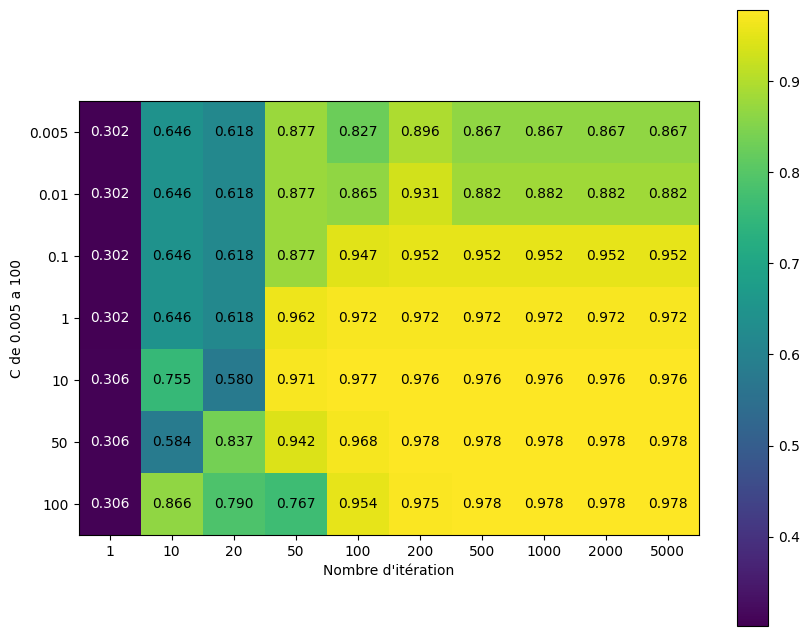

le meilleur resultat est :  0.978
Pour les valeurs de C et T suivante :  [{'C': 50, 'T': 200}, {'C': 50, 'T': 500}, {'C': 50, 'T': 1000}, {'C': 50, 'T': 2000}, {'C': 50, 'T': 5000}, {'C': 100, 'T': 500}, {'C': 100, 'T': 1000}, {'C': 100, 'T': 2000}, {'C': 100, 'T': 5000}]


In [45]:
#   3 - À l’aide des exemples de validation pour obtenir le taux d’exactitude, trouver les meilleurs hyper-paramètres en essayant les valeurs C {0.005, 0.01, 0.1, 1, 10, 50, 100} et
#       T {1, 10, 20, 50, 100, 200, 500,1000,2000,5000} ( le nombre d'itération) .Éffectuez une recherche en grille de ces paramètres.
#       Afficher un graphique de type «heat map» résumant les performances obtenues pour chaque combinaison de c et T . Expliquez l'impact de chaque hyper-paramètre. (5 pts)

import warnings
from sklearn.exceptions import ConvergenceWarning

# Désactiver les avertissements de convergence - Ligne généré grace a chatGPT
warnings.filterwarnings("ignore", category=ConvergenceWarning)

C = [0.005, 0.01, 0.1, 1, 10, 50, 100]
T = [1, 10, 20, 50, 100, 200, 500,1000,2000,5000]

#nb de combinaison => 7 x 10 = 70
exact = np.full((len(C),len(T)),-1.0)

for i, c in enumerate(C):
  for j,t in enumerate(T):
    SVC_model = SVC(C=c,kernel='rbf' ,random_state=42, max_iter=t)
    SVC_model.fit(X_2,y_2)
    y_resultat = SVC_model.predict(X_2)
    exact[i][j] = taux_exactitude(y_resultat,y_2)

print(exact)

affichage_heatmap(exact,T,C)

best, valeurs = meilleur_resultat_C_T(exact,C,T)
print("le meilleur resultat est : ", best)
print("Pour les valeurs de C et T suivante : ", valeurs)

#Les meilleurs combinaison donnans 0.978 sont : avec C = 50, T = 200,500,1000,2000,50000 ou c = 100 avec T = 500, 1000,2000, 5000

In [46]:
#   4 - À l'aide des données de test, utilisez la combinaison de C et T donnant les meilleurs performances et faites une inférence. Expliquez vos observations.(5 pts)

#ici nous allons prendre les plus petites des meilleurs résultat pour c et t
c=50
t=200

#On sépare les données
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# On va utiliser X_Train et y_Train pour l'entrainement et X_test et y_test pour tester
 #Entrainement sur les données :
SVC_model = SVC(C=c,kernel='rbf' ,random_state=42, max_iter=t)
SVC_model.fit(X_train,y_train)

#avec valeur de validation
y_resultat = SVC_model.predict(X_val)
print("exactitude :", taux_exactitude(y_resultat,y_val))

# On obtien un résultat presque parfait. On vois bien qu'une marge souple améliore grandement les résultats quand les données sont difficilement séparable

exactitude : 0.98


[[0.353 0.618 0.729 0.855 0.832 0.92  0.855 0.855 0.855 0.855]
 [0.353 0.618 0.729 0.852 0.836 0.917 0.876 0.876 0.876 0.876]
 [0.353 0.618 0.719 0.853 0.957 0.951 0.951 0.951 0.951 0.951]
 [0.353 0.623 0.788 0.957 0.971 0.971 0.971 0.971 0.971 0.971]
 [0.418 0.671 0.776 0.968 0.972 0.973 0.973 0.973 0.973 0.973]
 [0.418 0.716 0.672 0.943 0.973 0.975 0.977 0.977 0.977 0.977]
 [0.418 0.746 0.743 0.835 0.954 0.976 0.975 0.975 0.975 0.975]]
[[0.02040935 0.03432703 0.04027891 0.05000401 0.08112454 0.15046048
  0.27439642 0.27659822 0.2791965  0.28308296]
 [0.02071977 0.026016   0.03355002 0.05468202 0.09499669 0.18259382
  0.24431777 0.19121385 0.12600946 0.12423801]
 [0.01350927 0.01566625 0.01852536 0.02903152 0.0458262  0.05835056
  0.05981398 0.07141709 0.06051731 0.0577817 ]
 [0.01266837 0.01547503 0.01825333 0.03031683 0.03473949 0.03579688
  0.0354929  0.03718615 0.03581858 0.03612351]
 [0.01267314 0.01522565 0.01844835 0.02508116 0.02611399 0.02764177
  0.02889919 0.02880073 0.0287

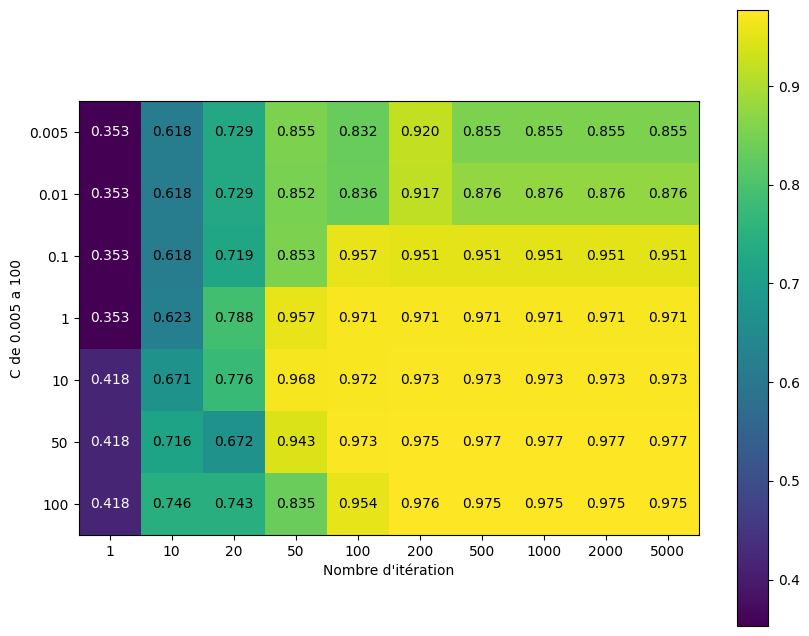

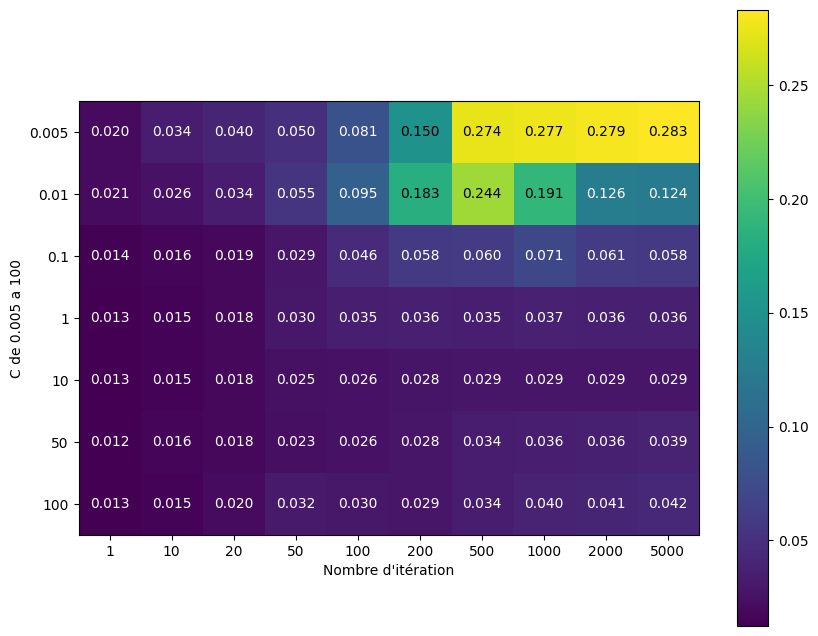

In [47]:
#   5 - Effectuez ensuite une validation croisée avec k=5 pour toutes les recherches en grilles précédentes(N'utilisez pas de bibliothèques).
#       Affichez le taux d'exactitude moyen pour chaque combinaison de T et de C à l'aide d'un graphique de type «heatmap». Calculez le temps d'entrainement pour chaque combinaison.
#       Pourquoi est-il intéressant de faire une validation croisée, en général? Que remarquez-vous au niveau du temps d'entrainement en fonction des hyper paramètres, en général?
#       Commentez et expliquez ce comportement. (5 pts)
K=5

C = [0.005, 0.01, 0.1, 1, 10, 50, 100]
T = [1, 10, 20, 50, 100, 200, 500,1000,2000,5000]

#Fonction de validation croiser avec marge souple
def validation_croiser_souple(X,Y,K,C,T):

  taille = len(X)//K
  exactitude_kFold = []
  debut_temps = time.time()

  for i in range(K):
    #definir les indices de debut et la fin de l'échantillon utiliser
    debut = i*taille
    fin = debut + taille
    #valeur de test
    X_test = X[debut:fin]
    Y_test = Y[debut:fin]
    #valeur d'entrainement
    X_train = np.concatenate((X[:debut], X[fin:])) #avant le debut et apres la fin
    Y_train = np.concatenate((Y[:debut],Y[fin:]))

    #effectuer l'entrainement sur cette base de donnée
    SVC_model = SVC(C=C,kernel='rbf' ,random_state=42, max_iter=T)
    SVC_model.fit(X_train,Y_train)

    #test les valeurs
    y_resultat = SVC_model.predict(X_test)
    exactitude_kFold.append(taux_exactitude(y_resultat,Y_test))

  fin_temps = time.time()
  temps_total = fin_temps - debut_temps
  return(exactitude_kFold,temps_total)

exact_moyen = np.full((len(C),len(T)),-1.0)
duree_temps = np.full((len(C),len(T)),-1.0)
for i, c in enumerate(C):
  for j,t in enumerate(T):
    accuracy_temporaire, duree_temporaire = validation_croiser_souple(X,y,K,c,t)
    exact_moyen[i][j] = np.mean(accuracy_temporaire)
    duree_temps[i][j] = duree_temporaire

print(exact_moyen)
print(duree_temps)

affichage_heatmap(exact_moyen,T,C)
affichage_heatmap(duree_temps,T,C)

# On remarque qu'avec la méthode de kfold jointe avec la marge souple, les résultat son meilleur, on obtien ici jusqua 0.975 d'exactitude dans un temps similaire.


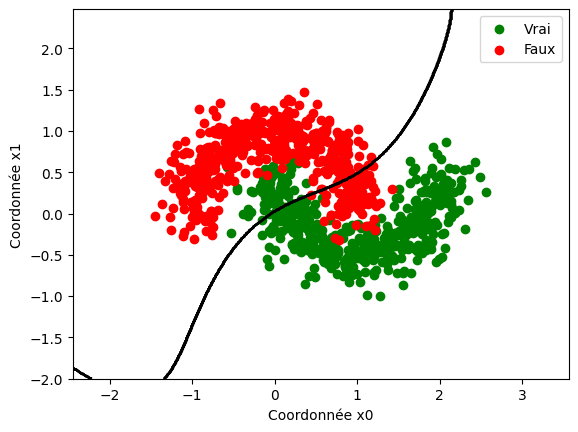

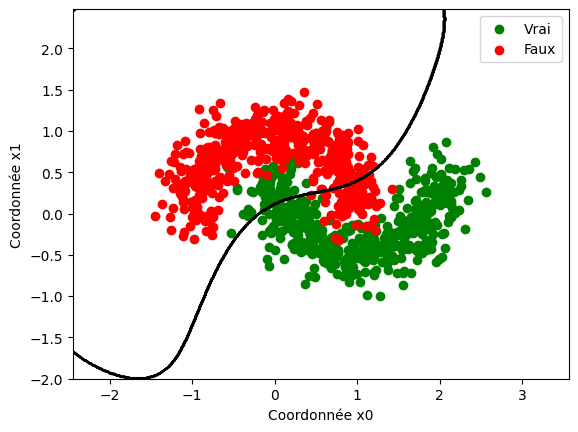

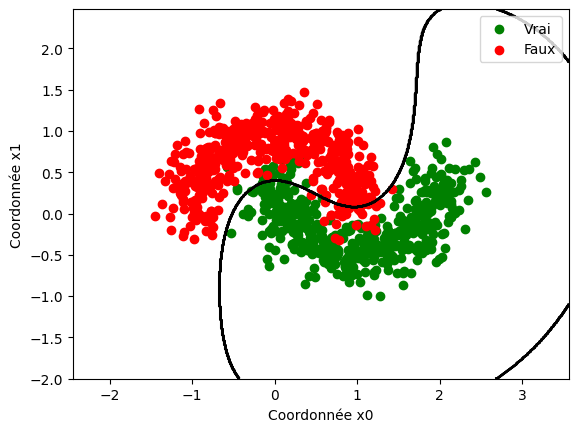

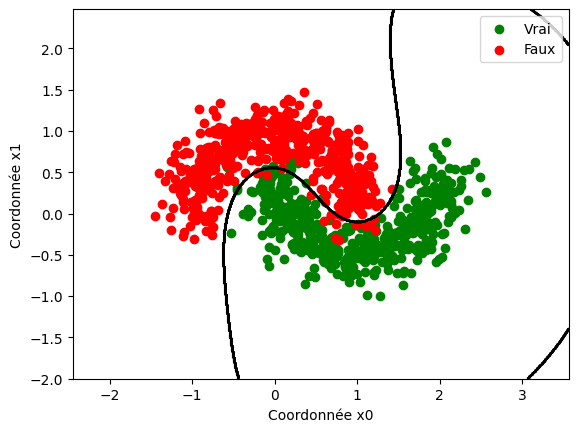

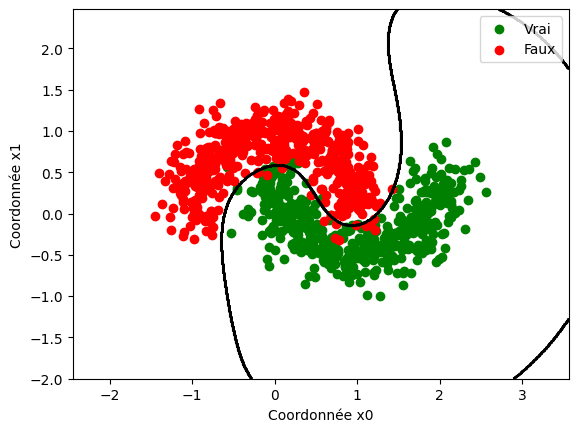

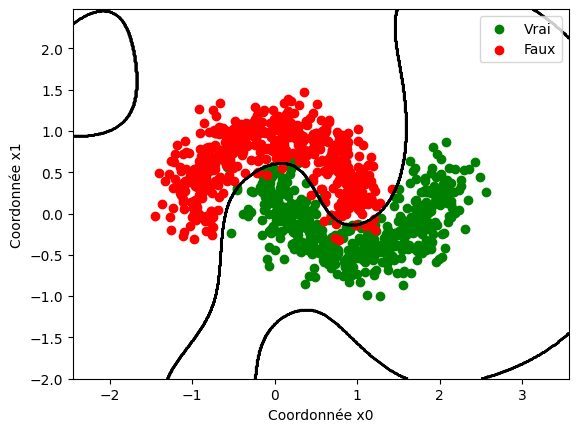

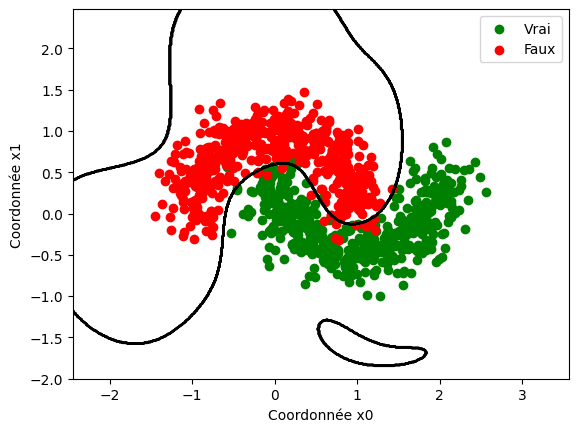

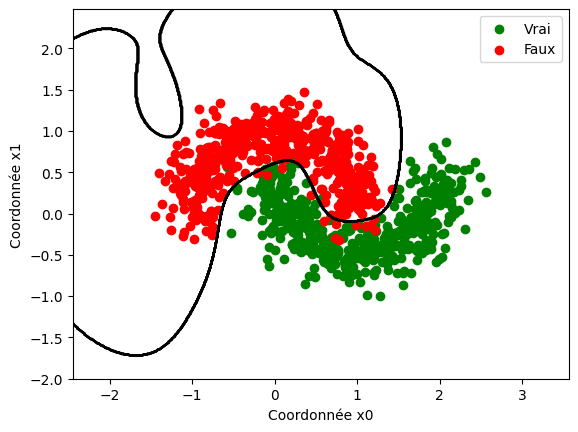

In [48]:
# #   6 - Affichez la frontière de décision pour T =5000 et C = {0.005, 0.01, 0.1, 1, 10, 50, 100, 1000}. Que remarquez vous? Quelles conclusions pouvez vous tirer quant au temps
# #       d'entrainement en fonction de C et expliquez ce phénomène? (5 pts)

# affichage_data(X_2,y_2)
C = [0.005, 0.01, 0.1, 1, 10, 50, 100, 1000]
T = 5000

for c in C:

  SVC_model = SVC(C=c,kernel='rbf' ,random_state=42, max_iter=t)
  SVC_model.fit(X_train,y_train)
  affichage_data_decision_souple(X_2,y_2,SVC_model)


# # Avec la suite de grafique ci-bas, on remarque qu'un petit c on tant vers le underfiting, tandis que plus la valeur de c augement, plus le fitting est maximisé jusqua devenir
#   overfitting avec de tres grande valeurs de C

## Exercise 3 (20 pts)
Le CIFAR-10 est un ensemble de données très utilisé en apprentissage automatique et vision par ordinateur. Il contient 60 000 images couleur de 32x32 pixels réparties en 10 classes différentes, chacune représentant un objet comme des avions, des automobiles, des oiseaux, des chats, des chiens, etc. L'ensemble est divisé en 50 000 images pour l'entraînement et 10 000 images pour les tests. CIFAR-10 est couramment utilisé pour entraîner des modèles de classification d'images et évaluer leurs performances.
### Questions
un code vous est fourni dans lequel est testé le SVM linéaire et le SVM à noyaux. Les images, comportant 32x32 = 1024 dimensions prendraient trop de temps et de puissance de calcul pour en faire l'analyse. Une réduction de la dimensionnalité(PCA) a été éffectuée en vue d'accélérer l'entrainement.
1. Faites rouler le code. **prévoyez de 20 à 40 minutes pour l'éxécution du code!**

2. Éxaminez les tableaux thermiques pour le SVM linéaire et le SVM à noyaux. Que remarquez vous? Commentez et expliquez les différences. (10 pts)

3. Éxaminez les tableaux de temps d'entrainement( en seconde). Que remarquez vous? Commentez et expliquez les différences. (10 pts)

4. Modifiez le code pour utiliser un CNN-2D à la place d'un SVM. Commentez et expliquez les différences.(**BONUS**) (5 pts)

Entraînement avec le noyau linear


Entraînement des valeurs de C (noyau=linear): 100%|██████████| 6/6 [18:05<00:00, 180.91s/it]


Entraînement avec le noyau rbf


Entraînement des valeurs de C (noyau=rbf): 100%|██████████| 6/6 [33:04<00:00, 330.72s/it]


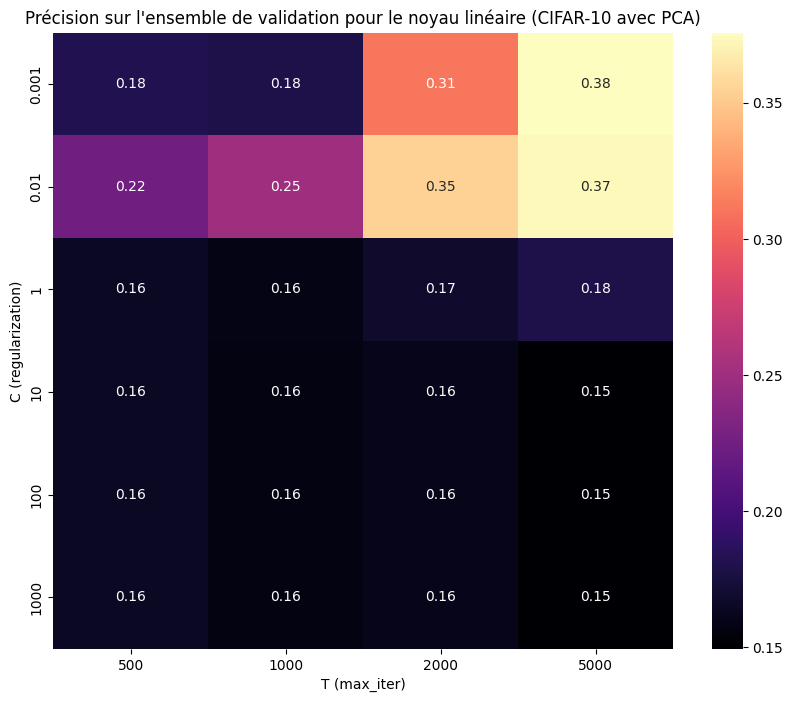

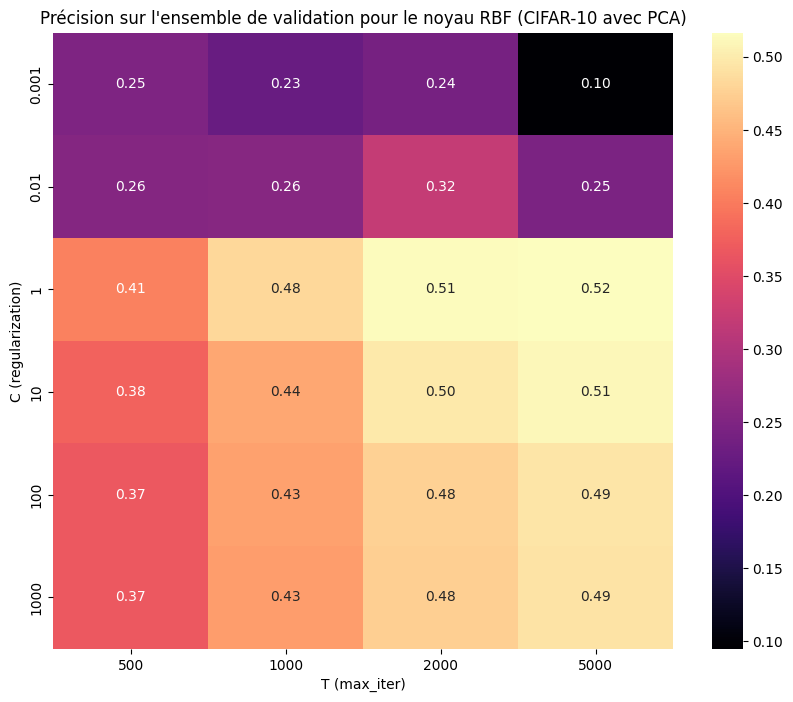

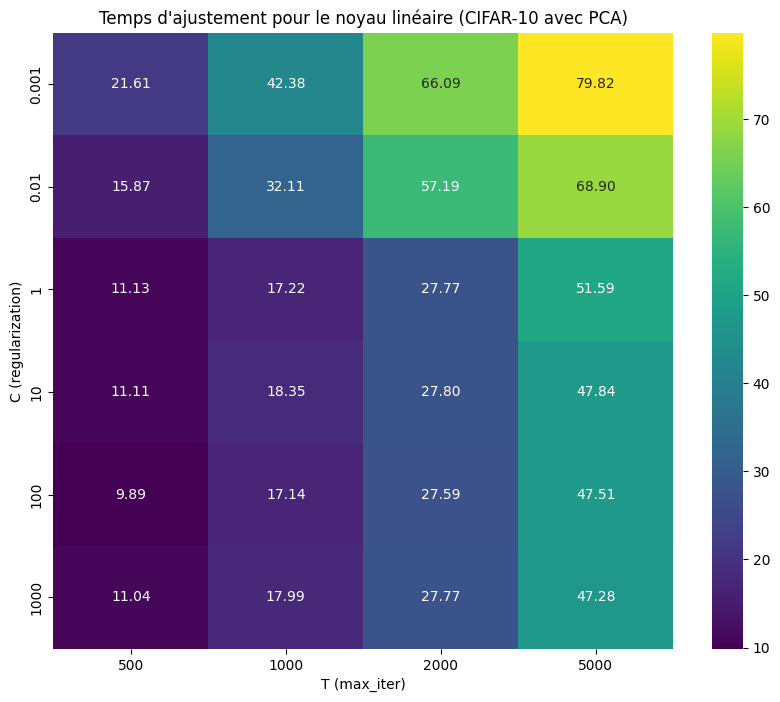

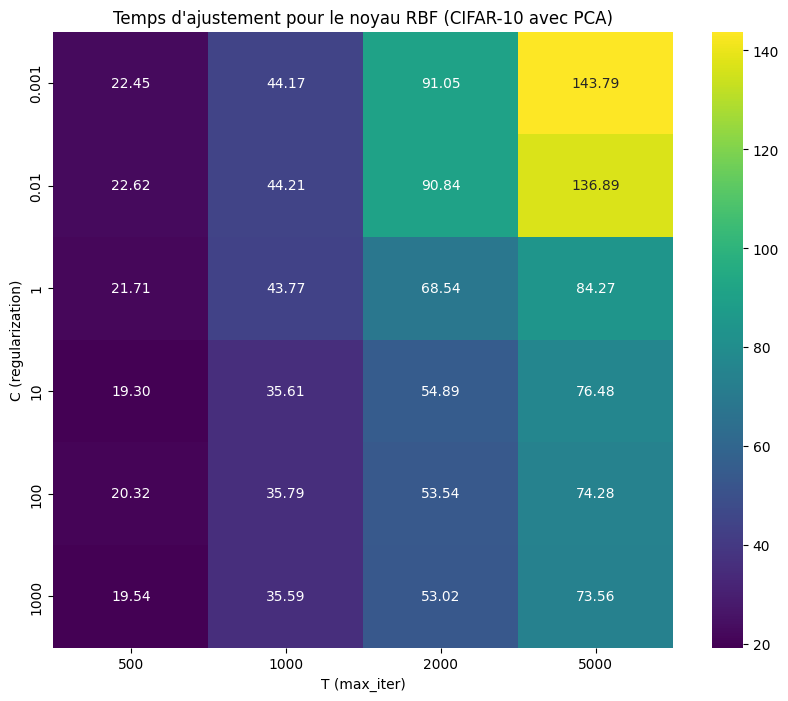

Meilleure précision de validation pour le noyau linéaire : 0.3757 (C=0.001, T=5000)
Précision sur l'ensemble de test avec le noyau linéaire : 0.3871
Meilleure précision de validation pour le noyau RBF : 0.5165 (C=1, T=5000)
Précision sur l'ensemble de test avec le noyau RBF : 0.5292


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from keras.datasets import cifar10
import seaborn as sns
import time
from tqdm import tqdm  # Import tqdm for progress bar

# Load the CIFAR-10 dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

# Flatten images for SVM (SVM requires 2D arrays)
X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_full = X_test_full.reshape(X_test_full.shape[0], -1)

# Convert labels to 1D arrays
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Use PCA to reduce dimensionality (reduce to 50 components for faster training)
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca = pca.transform(X_test_full)

# Split the data into training (60%), validation (20%), and test sets (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X_train_pca, y_train_full, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define the parameter ranges
C_values = [0.001, 0.01, 1, 10, 100, 1000]  # Regularization parameter
T_values = [500, 1000, 2000, 5000]  # Maximum iterations
kernels = ['linear', 'rbf']  # Try both linear and RBF kernels

# Initialize arrays to store validation and test results
validation_results = {kernel: np.zeros((len(C_values), len(T_values))) for kernel in kernels}
test_results = {kernel_type: 0 for kernel_type in kernels}  # For test set accuracy
fit_times = {kernel: np.zeros((len(C_values), len(T_values))) for kernel in kernels}  # Store fit times

# Train on the training set and evaluate on validation and test sets
for kernel_type in kernels:
    print(f"Entraînement avec le noyau {kernel_type}")

    # Use tqdm to create a progress bar
    for i, C_value in enumerate(tqdm(C_values, desc=f'Entraînement des valeurs de C (noyau={kernel_type})')):
        for j, T_value in enumerate(T_values):
            # Create and train the model
            model = SVC(kernel=kernel_type, C=C_value, max_iter=T_value, random_state=42)

            # Measure the training time
            start_time = time.time()
            model.fit(X_train_scaled, y_train)
            fit_time = time.time() - start_time
            fit_times[kernel_type][i, j] = fit_time

            # Predict and evaluate on validation set
            y_val_pred = model.predict(X_val_scaled)
            validation_results[kernel_type][i, j] = accuracy_score(y_val, y_val_pred)

# Find the best hyperparameters from the validation set
best_results = {}
for kernel_type in kernels:
    best_indices = np.unravel_index(np.argmax(validation_results[kernel_type], axis=None), validation_results[kernel_type].shape)
    best_C = C_values[best_indices[0]]
    best_T = T_values[best_indices[1]]

    # Now train the model on the full training set with the best hyperparameters and evaluate on the test set
    best_model = SVC(kernel=kernel_type, C=best_C, max_iter=best_T, random_state=42)
    best_model.fit(X_train_scaled, y_train)

    # Predict and evaluate on the test set
    y_test_pred = best_model.predict(X_test_scaled)
    test_results[kernel_type] = accuracy_score(y_test, y_test_pred)

    best_results[kernel_type] = (best_C, best_T, validation_results[kernel_type][best_indices])

# Plot the heatmap for validation set results for linear kernel
plt.figure(figsize=(10, 8))
sns.heatmap(validation_results['linear'], annot=True, fmt=".2f", xticklabels=T_values, yticklabels=C_values, cmap="magma")
plt.title("Précision sur l'ensemble de validation pour le noyau linéaire (CIFAR-10 avec PCA)")
plt.xlabel("T (max_iter)")
plt.ylabel("C (regularization)")
plt.show()

# Plot the heatmap for validation set results for RBF kernel
plt.figure(figsize=(10, 8))
sns.heatmap(validation_results['rbf'], annot=True, fmt=".2f", xticklabels=T_values, yticklabels=C_values, cmap="magma")
plt.title("Précision sur l'ensemble de validation pour le noyau RBF (CIFAR-10 avec PCA)")
plt.xlabel("T (max_iter)")
plt.ylabel("C (regularization)")
plt.show()

# Plot the heatmap for fitting times for linear kernel
plt.figure(figsize=(10, 8))
sns.heatmap(fit_times['linear'], annot=True, fmt=".2f", xticklabels=T_values, yticklabels=C_values, cmap="viridis")
plt.title("Temps d'ajustement pour le noyau linéaire (CIFAR-10 avec PCA)")
plt.xlabel("T (max_iter)")
plt.ylabel("C (regularization)")
plt.show()

# Plot the heatmap for fitting times for RBF kernel
plt.figure(figsize=(10, 8))
sns.heatmap(fit_times['rbf'], annot=True, fmt=".2f", xticklabels=T_values, yticklabels=C_values, cmap="viridis")
plt.title("Temps d'ajustement pour le noyau RBF (CIFAR-10 avec PCA)")
plt.xlabel("T (max_iter)")
plt.ylabel("C (regularization)")
plt.show()

# Print the best results for each kernel
print(f"Meilleure précision de validation pour le noyau linéaire : {best_results['linear'][2]:.4f} (C={best_results['linear'][0]}, T={best_results['linear'][1]})")
print(f"Précision sur l'ensemble de test avec le noyau linéaire : {test_results['linear']:.4f}")
print(f"Meilleure précision de validation pour le noyau RBF : {best_results['rbf'][2]:.4f} (C={best_results['rbf'][0]}, T={best_results['rbf'][1]})")
print(f"Précision sur l'ensemble de test avec le noyau RBF : {test_results['rbf']:.4f}")

In [ ]:
#Q1 Faites rouler le code. prévoyez de 20 à 40 minutes pour l'éxécution du code!

#Q2 Éxaminez les tableaux thermiques pour le SVM linéaire et le SVM à noyaux. Que remarquez vous? Commentez et expliquez les différences. (10 pts)
#  Noyau linéaire - T = 5000 C = 0.001 avec un temps d'ajustement de 79.82
#  Noyau RBF      - T = 5000 C = 1     avec un temps d'ajustement de 84.27
#   Dans le cas du linéaire, la meilleur réponse est aussi celle qui prend le plus de temps a généré. Par contre, dans le cas du RBF, ce n'est pas le cas
#   La meilleur réponse prend presque la moitié du temps de la plus longue des validation (sois 84.27 vs 143.79). Il est donc possible d'avoir une réponse
#   meilleur en moins de temps. Même que l'utilisation d'un C plus petit ne donne pas de bon résultat. On vois que pour C = 0.001 et C = 0.01, nous avons des
#   résultat entre 0.1 et 0.32 de précision pour le RBF, tandis que pour le linéaire, c'est avec ses valeurs de C que la précision est la plus haute.

#Q3 Éxaminez les tableaux de temps d'entrainement( en seconde). Que remarquez vous? Commentez et expliquez les différences. (10 pts)
#   Voir question précédente pour les comparaisons de temps.

#Q4 Modifiez le code pour utiliser un CNN-2D à la place d'un SVM. Commentez et expliquez les différences.(BONUS) (5 pts)

## Exercise 4 : SVMs sur MNIST (30 pts)

**Pour cette partie, vous n'avez aucune restriction pour l'utilisation de bibliothèque.**

Le jeu de données MNIST est l'un des ensembles de données les plus connus et largement utilisés dans le domaine de l'apprentissage automatique. Il contient 70 000 images de chiffres écrits à la main, de 0 à 9, avec chaque image de taille 28x28 pixels en niveaux de gris. Les 60 000 premières images sont utilisées pour l'entraînement, tandis que les 10 000 restantes servent à l'évaluation. Le but est de classifier chaque image en identifiant le chiffre qu'elle représente. MNIST est souvent utilisé comme benchmark pour tester des algorithmes de classification, car il s'agit d'un problème de reconnaissance d'images relativement simple mais qui permet d'explorer des concepts avancés tels que la réduction de dimensionnalité, la régularisation, et la recherche d'hyperparamètres.

1. Téléchargez le jeu de données MNIST et divisez-le en ensembles d'entraînement, de validation, et de test (5 pts):
python
from keras.datasets import mnist

2. Imprimez une image de chaque classe. Applatissez ensuites toutes les images. Imprimez un vecteur unidimensionnel correspondants au images précédentes.(5 pts).

3.  Diviser les données en ensembles d'entraînement, de validation et de test de la facon suivante(5 pts) :
- 60% données entrainement
- 20% données de validation
- 20% données de test

4. Effectuez une recherche en grille avec les données d'entrainement et de validation pour trouver les meilleurs hyperparamètres C et T selon «5 fold» entre les classes du chiffre 8 et du chiffre 3. Utilisez C_values = [0.001, 0.01, 1, 10, 100, 1000] et T_values = [500, 1000, 2000, 5000]. Pour chaque combinaison, affichez la précision sur l'ensemble de validation à l'aide d'un graphique de type "heatmap". Expliquez les impacts de chaque hyperparamètre sur la précision. Effectuez ceci pour le noyaux linéaire et le noyaux RBF. Commentez les résultats. (10 pts)

5. Répétez le numéro 4 avec les chiffre 8 et 0. Que remarquez vous? Donnez une hypothèse pour expliquer la différence.

6. en utilisant la meilleure combinaison de C et T trouvé au numéro 4, entrainez les SVM au noyau linéaire et au noyau RBF sur les 10 classes. Commentez les résultats. Que remarquez vous? (5pts)

5. Ajoutez une étape de réduction de dimensionnalité en utilisant PCA pour réduire les données à 50 dimensions. Comparez les résultats (précision et temps d'entraînement)  avec ceux obtenus sans réduction de dimension  numéro 4 . Commentez sur l'impact de la réduction de dimensionnalité sur le modèle.(**bonus**)(5 pts)

In [54]:
#Q1 Téléchargez le jeu de données MNIST et divisez-le en ensembles d'entraînement, de validation, et de test (5 pts): python from keras.datasets import mnist
from keras.datasets import mnist
from sklearn.model_selection import train_test_split

# Load the MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Flatten the images for SVM (SVM requires 2D arrays)
X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 48000
Validation set size: 12000
Test set size: 10000


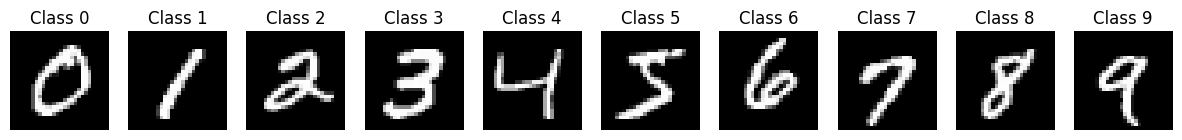

Flattened vector for class 0:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  51 159 253 159  50   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252
 253 122   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 163 252 252 252 

In [55]:
#Q2 Imprimez une image de chaque classe. Applatissez ensuites toutes les images. Imprimez un vecteur unidimensionnel correspondants au images précédentes.(5 pts).

import numpy as np
from keras.datasets import mnist

import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Print an image of each class
classes = np.unique(y_train_full)
fig, axes = plt.subplots(1, 10, figsize=(15, 15))
for i, cls in enumerate(classes):
    idx = np.where(y_train_full == cls)[0][0]
    axes[i].imshow(X_train_full[idx], cmap='gray')
    axes[i].set_title(f"Class {cls}")
    axes[i].axis('off')
plt.show()

# Flatten all images
X_train_full_flattened = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)

# Print a flattened vector corresponding to the first image of each class
for cls in classes:
    idx = np.where(y_train_full == cls)[0][0]
    print(f"Flattened vector for class {cls}:\n{X_train_full_flattened[idx]}\n")

In [56]:
#Q3 Diviser les données en ensembles d'entraînement, de validation et de test de la facon suivante(5 pts) :
#   60% données entrainement    (42k)
#   20% données de validation   (14k)
#   20% données de test         (14k)

from sklearn.model_selection import train_test_split

# First, split the data into 60% training and 40% temporary (which will be further split into validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(X_train_full_flattened, y_train_full, test_size=0.4, random_state=42)

# Then, split the temporary set into 50% validation and 50% test (which is 20% of the original data each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 36000
Validation set size: 12000
Test set size: 12000


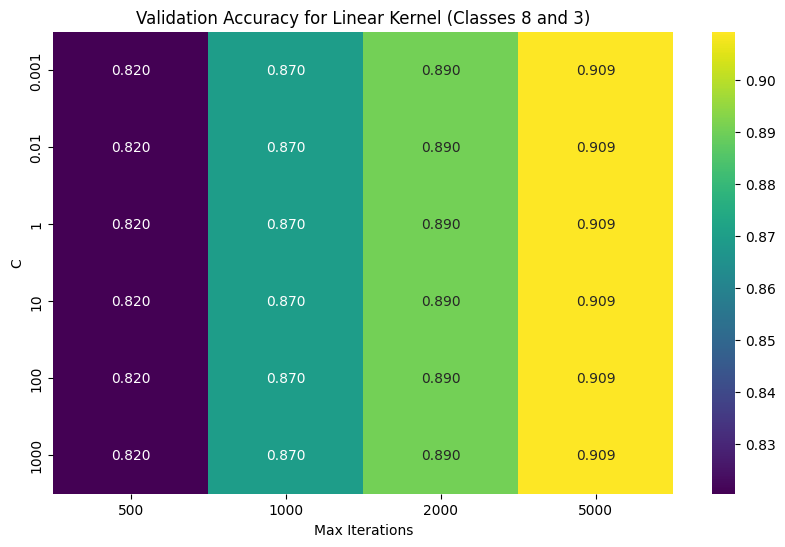

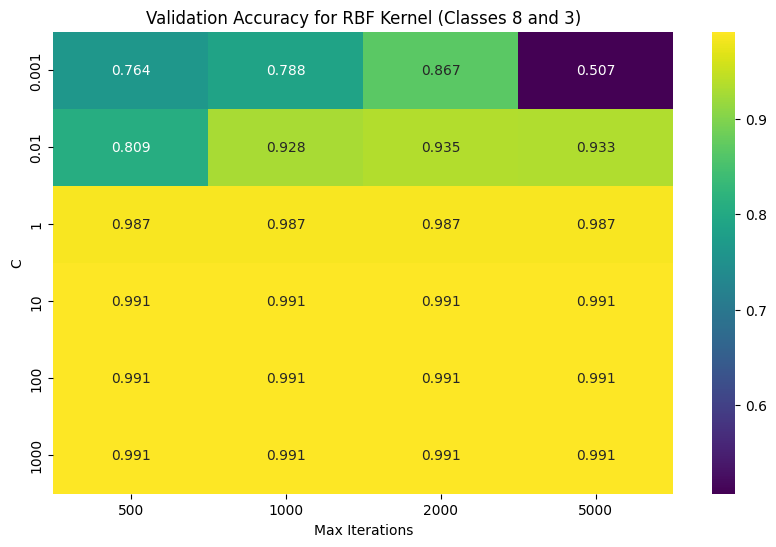

Best parameters for linear kernel: {'C': 0.001, 'max_iter': 5000}
Best validation accuracy for linear kernel: 0.9093593816599188
Best parameters for RBF kernel: {'C': 10, 'max_iter': 2000}
Best validation accuracy for RBF kernel: 0.991380005238532


In [60]:
#Q4 Effectuez une recherche en grille avec les données d'entrainement et de validation pour trouver les meilleurs hyperparamètres C et T selon «5 fold» entre les
#   classes du chiffre 8 et du chiffre 3. Utilisez C_values = [0.001, 0.01, 1, 10, 100, 1000] et T_values = [500, 1000, 2000, 5000]. Pour chaque combinaison,
#   affichez la précision sur l'ensemble de validation à l'aide d'un graphique de type "heatmap". Expliquez les impacts de chaque hyperparamètre sur la précision.
#   Effectuez ceci pour le noyaux linéaire et le noyaux RBF. Commentez les résultats. (10 pts)

from sklearn.model_selection import GridSearchCV
import seaborn as sns

# Filter the data for classes 8 and 3
indices = np.where((y_train == 8) | (y_train == 3))
X_train_83 = X_train[indices]
y_train_83 = y_train[indices]

indices_val = np.where((y_val == 8) | (y_val == 3))
X_val_83 = X_val[indices_val]
y_val_83 = y_val[indices_val]

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 1, 10, 100, 1000],
    'max_iter': [500, 1000, 2000, 5000]
}

# Perform grid search for linear kernel
svc_linear = SVC(kernel='linear')
grid_search_linear = GridSearchCV(svc_linear, param_grid, cv=5, scoring='accuracy')
grid_search_linear.fit(X_train_83, y_train_83)

# Perform grid search for RBF kernel
svc_rbf = SVC(kernel='rbf')
grid_search_rbf = GridSearchCV(svc_rbf, param_grid, cv=5, scoring='accuracy')
grid_search_rbf.fit(X_train_83, y_train_83)

# Extract results
results_linear = grid_search_linear.cv_results_
results_rbf = grid_search_rbf.cv_results_

# Reshape the results for heatmap
scores_linear = results_linear['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['max_iter']))
scores_rbf = results_rbf['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['max_iter']))

# Plot heatmap for linear kernel
plt.figure(figsize=(10, 6))
sns.heatmap(scores_linear, annot=True, fmt=".3f", xticklabels=param_grid['max_iter'], yticklabels=param_grid['C'], cmap="viridis")
plt.title("Validation Accuracy for Linear Kernel (Classes 8 and 3)")
plt.xlabel("Max Iterations")
plt.ylabel("C")
plt.show()

# Plot heatmap for RBF kernel
plt.figure(figsize=(10, 6))
sns.heatmap(scores_rbf, annot=True, fmt=".3f", xticklabels=param_grid['max_iter'], yticklabels=param_grid['C'], cmap="viridis")
plt.title("Validation Accuracy for RBF Kernel (Classes 8 and 3)")
plt.xlabel("Max Iterations")
plt.ylabel("C")
plt.show()

# Print best parameters and scores
print("Best parameters for linear kernel:", grid_search_linear.best_params_)
print("Best validation accuracy for linear kernel:", grid_search_linear.best_score_)
print("Best parameters for RBF kernel:", grid_search_rbf.best_params_)
print("Best validation accuracy for RBF kernel:", grid_search_rbf.best_score_)

PCA Done


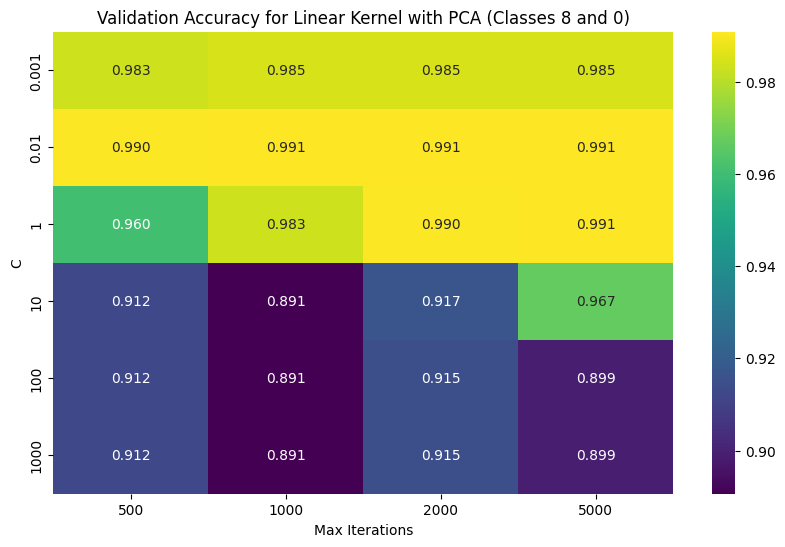

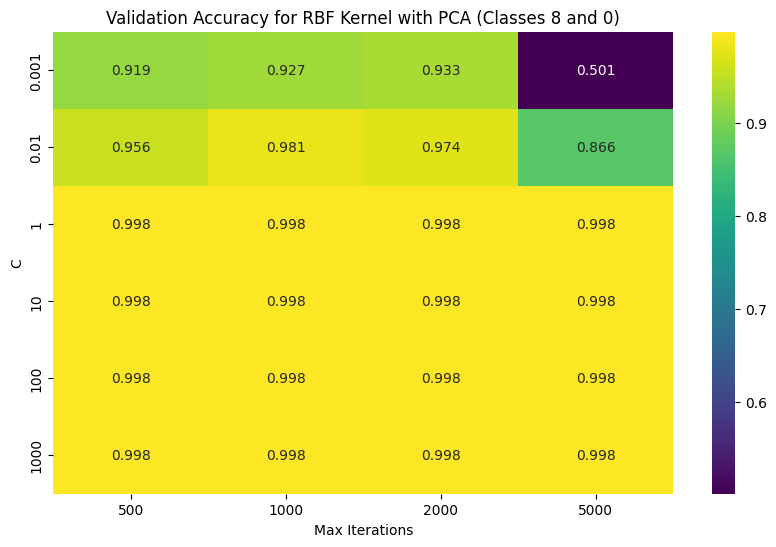

Best parameters for linear kernel with PCA: {'C': 1, 'max_iter': 5000}
Best validation accuracy for linear kernel with PCA: 0.9908515130190005
Best parameters for RBF kernel with PCA: {'C': 1, 'max_iter': 1000}
Best validation accuracy for RBF kernel with PCA: 0.9981703026038001


NameError: name 'fit_times' is not defined

In [61]:
#Q5 Répétez le numéro 4 avec les chiffre 8 et 0. Que remarquez vous? Donnez une hypothèse pour expliquer la différence.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time
import seaborn as sns

import matplotlib.pyplot as plt

# Apply PCA to reduce the data to 50 dimensions
# Filter the data for classes 8 and 3
indices = np.where((y_train == 8) | (y_train == 0))
X_train_80 = X_train[indices]
y_train_80 = y_train[indices]

indices_val = np.where((y_val == 8) | (y_val == 0))
X_val_80 = X_val[indices_val]
y_val_80 = y_val[indices_val]

pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_80)
X_val_pca = pca.transform(X_val_80)
X_test_pca = pca.transform(X_test)

# Normalize the features
scaler = StandardScaler()
X_train_pca_scaled = scaler.fit_transform(X_train_pca)
X_val_pca_scaled = scaler.transform(X_val_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)

print("PCA Done")

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 1, 10, 100, 1000],
    'max_iter': [500, 1000, 2000, 5000]
}

# Perform grid search for linear kernel with PCA
svc_linear_pca = SVC(kernel='linear')
grid_search_linear_pca = GridSearchCV(svc_linear_pca, param_grid, cv=5, scoring='accuracy')

start_time = time.time()
grid_search_linear_pca.fit(X_train_pca_scaled, y_train_80)
linear_pca_fit_time = time.time() - start_time

# Perform grid search for RBF kernel with PCA
svc_rbf_pca = SVC(kernel='rbf')
grid_search_rbf_pca = GridSearchCV(svc_rbf_pca, param_grid, cv=5, scoring='accuracy')

start_time = time.time()
grid_search_rbf_pca.fit(X_train_pca_scaled, y_train_80)
rbf_pca_fit_time = time.time() - start_time

# Extract results
results_linear_pca = grid_search_linear_pca.cv_results_
results_rbf_pca = grid_search_rbf_pca.cv_results_

# Reshape the results for heatmap
scores_linear_pca = results_linear_pca['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['max_iter']))
scores_rbf_pca = results_rbf_pca['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['max_iter']))

# Plot heatmap for linear kernel with PCA
plt.figure(figsize=(10, 6))
sns.heatmap(scores_linear_pca, annot=True, fmt=".3f", xticklabels=param_grid['max_iter'], yticklabels=param_grid['C'], cmap="viridis")
plt.title("Validation Accuracy for Linear Kernel with PCA (Classes 8 and 0)")
plt.xlabel("Max Iterations")
plt.ylabel("C")
plt.show()

# Plot heatmap for RBF kernel with PCA
plt.figure(figsize=(10, 6))
sns.heatmap(scores_rbf_pca, annot=True, fmt=".3f", xticklabels=param_grid['max_iter'], yticklabels=param_grid['C'], cmap="viridis")
plt.title("Validation Accuracy for RBF Kernel with PCA (Classes 8 and 0)")
plt.xlabel("Max Iterations")
plt.ylabel("C")
plt.show()

# Print best parameters and scores
print("Best parameters for linear kernel with PCA:", grid_search_linear_pca.best_params_)
print("Best validation accuracy for linear kernel with PCA:", grid_search_linear_pca.best_score_)
print("Best parameters for RBF kernel with PCA:", grid_search_rbf_pca.best_params_)
print("Best validation accuracy for RBF kernel with PCA:", grid_search_rbf_pca.best_score_)

# Compare training times
print("Training time for linear kernel without PCA:", fit_times['linear'])
print("Training time for linear kernel with PCA:", linear_pca_fit_time)
print("Training time for RBF kernel without PCA:", fit_times['rbf'])
print("Training time for RBF kernel with PCA:", rbf_pca_fit_time)

In [ ]:
#Q6 En utilisant la meilleure combinaison de C et T trouvé au numéro 4, entrainez les SVM au noyau linéaire et au noyau RBF sur les 10 classes. Commentez les résultats.
#   Que remarquez vous? (5pts)

# Best parameters for linear and RBF kernels
best_C_linear = grid_search_linear.best_params_['C']
best_T_linear = grid_search_linear.best_params_['max_iter']
best_C_rbf = grid_search_rbf.best_params_['C']
best_T_rbf = grid_search_rbf.best_params_['max_iter']

# Train SVM with linear kernel on 10 classes
svm_linear = SVC(kernel='linear', C=best_C_linear, max_iter=best_T_linear, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy with linear kernel on 10 classes: {accuracy_linear}")

# Train SVM with RBF kernel on 10 classes
svm_rbf = SVC(kernel='rbf', C=best_C_rbf, max_iter=best_T_rbf, random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy with RBF kernel on 10 classes: {accuracy_rbf}")

#Q7 Ajoutez une étape de réduction de dimensionnalité en utilisant PCA pour réduire les données à 50 dimensions. Comparez les résultats (précision et temps d'entraînement)
#   avec ceux obtenus sans réduction de dimension numéro 4 . Commentez sur l'impact de la réduction de dimensionnalité sur le modèle.(bonus)(5 pts)


## Exercise 5 : kNN (20 pts)

Pour cet exercice, nous allons implémenter un classificateur des k plus proches voisins (*k-Nearest Neighbors* ou *k-NN*).

### Rappels de cours

Le classificateur des k plus proches voisins est un algorithme qui classifie les objets selon leur proximité aux données d’entraînement. C’est une approche de modélisation simple qui approxime la frontière de décision localement. Il n’y a pas d’entraînement à proprement parler et les calculs sont seulement effectués lors de la classification. Comme la figure ci-dessous le montre, la classification d’un exemple est effectuée en choisissant la classe la plus fréquente parmi les plus proches voisins. Bien que plusieurs mesures de distance puissent être utilisées pour définir le voisinage, la mesure la plus utilisée est la distance Euclidienne, définie par :
\begin{equation*}
d(p,q) = \sqrt{\sum_{i=1}^{d}(p_i - q_i)^2}
\end{equation*}

où $p$ et $q$ sont deux points dans un espace ${\mathbb R}^d$.

<img src=images/kNN.png style="width: 300px;">

Dans cette figure, si on ne considère que 3 voisins on attribuera la classe A alors que si on considère 7 voisins, on attribuera plutôt la classe B.

Normalement, un kNN ne génère pas de probabilités, car il renvoie simplement la classe majoritaire. Dans cet exercice, on va modifier la fonction de classification pour introduire la notion de probabilité.
\begin{equation*}
P(C_j | {\bf x}) = \dfrac{n_j}{k}
\end{equation*}
où $n$ est le nombre de plus proches voisins appartenant à la classe $C_j$ et $k$ le nombre total de plus proches voisins considérés.

Le classificateur kNN est une méthode non paramétrique qui ne nécessite pas d’établir une hypothèse au préalable sur la nature des distributions de données (contrairement à un Perceptron par exemple). Le seul paramètre à déterminer est la taille du voisinage $k$. On choisit ce paramètre à partir des données.

### Questions

1. Charger les données du datatset Iris à l’aide de la fonction `sklearn.datasets.load_iris`. (5 pts)
2. Séparer aléatoirement les données en deux parties (entrainement et test) de manière balancée avec la fonction `sklearn.model_selection.train_test_split`. (5 pts)
3. Implémenter un kNN permettant d’utiliser n’importe quel $k$ en paramètre en utilisant la classe fournie ci-dessous(5 pts) :
    * La méthode `fit` sert à charger les données et déterminer les classes du problème.
    * La méthode `predict_proba` prend en entrée des données `X` et renvoie les probabilités prédites pour chaque classe du problème.
    * La méthode `predict` prend en entrée des données `X` et renvoie la classe prédite pour chaque échantillon.
4. Calculer et tracer le taux d'exactitude pour 1-NN, 2-NN jusqu’à 10-NN. Commenter ces résultats. Quels sont les limitations de cette méthode d’évaluation ? (5 pts)

In [ ]:
import numpy as np
from scipy.stats import mode

class kNN(object):
    def __init__(self, k: int) -> None:
        """
        Classificateur kNN.

        Parameters
        ----------
        k : int
            Nombre de plus proches voisins utilisés pour classifier un nouveau point.

        """
        self.k = k

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Chargement des données.

        Parameters
        ----------
        X : np.ndarray
            Données d'entrainement. Taille : (# exemples, # entrées).
        y : np.ndarray
            Étiquettes des données d'entrainement. Taille : (# exemples,).

        """
        self.X_train = X
        self.y_train = y
        self.classes = np.unique(y)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Fonction de classification du kNN pour un ou plusieurs points.

        Parameters
        ----------
        X : np.ndarray
            Donnée(s) d'entrée à classifier. Taille : (# exemples, # entrées).

        Returns
        -------
        probabilities : np.ndarray
            Vecteur(s) de probabilités prédits pour chaque données d'entrée. Taille : (# exemples, # classes).

        """
        distances = np.linalg.norm(self.X_train[:, np.newaxis] - X, axis=2)
        nearest_neighbors = np.argsort(distances, axis=0)[:self.k]
        nearest_labels = self.y_train[nearest_neighbors]

        probabilities = np.zeros((X.shape[0], len(self.classes)))
        for i in range(X.shape[0]):
            class_counts = np.bincount(nearest_labels[:, i], minlength=len(self.classes))
            probabilities[i] = class_counts / self.k

        return probabilities

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Fonction de classification du kNN pour un ou plusieurs points

        Parameters
        ----------
        X : np.ndarray
            Donnée(s) d'entrée à classifier. Taille : (# exemples, # entrées).

        Returns
        -------
        y_pred : np.ndarray
            Étiquette(s) prédite(s) pour chaque donnée d'entrée.. Taille : (# exemples,).

        """
        probabilities = self.predict_proba(X)
        y_pred = np.argmax(probabilities, axis=1)
        return y_pred

In [ ]:
#Q1 Charger les données du datatset Iris à l’aide de la fonction sklearn.datasets.load_iris. (5 pts)
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Features:", X[:5])
print("Labels:", y[:5])

Features: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Labels: [0 0 0 0 0]


In [ ]:
#Q2 Séparer aléatoirement les données en deux parties (entrainement et test) de manière balancée avec la fonction sklearn.model_selection.train_test_split. (5 pts)
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 120
Test set size: 30


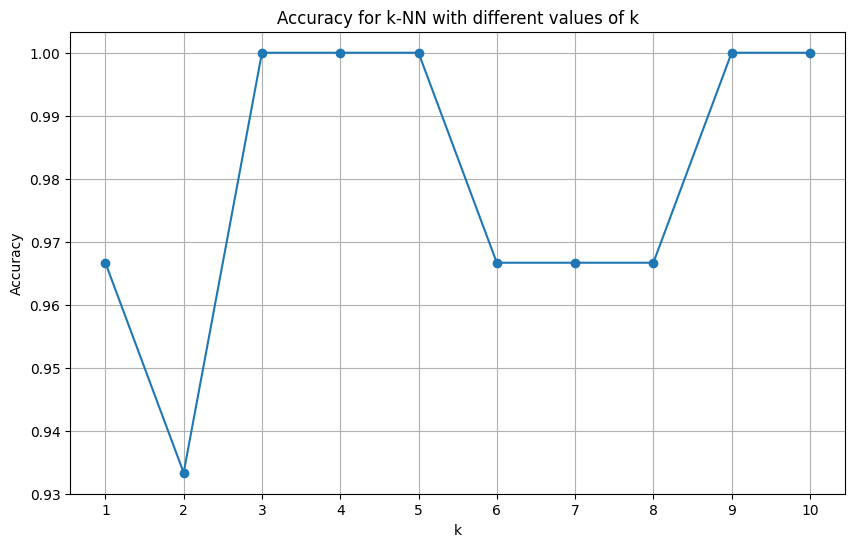

Accuracy for 1-NN: 0.97
Accuracy for 2-NN: 0.93
Accuracy for 3-NN: 1.00
Accuracy for 4-NN: 1.00
Accuracy for 5-NN: 1.00
Accuracy for 6-NN: 0.97
Accuracy for 7-NN: 0.97
Accuracy for 8-NN: 0.97
Accuracy for 9-NN: 1.00
Accuracy for 10-NN: 1.00


In [ ]:
#Q3 Implémenter un kNN permettant d’utiliser n’importe quel  k  en paramètre en utilisant la classe fournie ci-dessous(5 pts) :
#   - La méthode fit sert à charger les données et déterminer les classes du problème.
#   - La méthode predict_proba prend en entrée des données X et renvoie les probabilités prédites pour chaque classe du problème.
#   - La méthode predict prend en entrée des données X et renvoie la classe prédite pour chaque échantillon.

#Q4 Calculer et tracer le taux d'exactitude pour 1-NN, 2-NN jusqu’à 10-NN. Commenter ces résultats. Quels sont les limitations de cette méthode d’évaluation ? (5 pts)
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

# Initialize lists to store the values of k and corresponding accuracies
k_values = list(range(1, 11))
accuracies = []

# Loop through values of k from 1 to 10
for k in k_values:
    knn = kNN(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Plot the accuracies
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy for k-NN with different values of k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Print the accuracies
for k, accuracy in zip(k_values, accuracies):
    print(f'Accuracy for {k}-NN: {accuracy:.2f}')

## Exercice 6 (20 pts) : Classificateur Bayésien naïf

Le but de cet exercice est d’implémenter un classificateur Bayésien naïf dans lequel on fait les suppositions suivantes :

- Les caractéristiques du problème sont indépendantes ;
- Les caractéristiques suivent des distributions gaussiennes :

  $$
  P(x | \mu_k, \sigma_k) = \frac{1}{\sigma_k \sqrt{2\pi}} \exp\left( -\frac{(x - \mu_k)^2}{2\sigma_k^2} \right)
  $$

  où $\mu_k$ et $\sigma_k$ sont la moyenne et l'écart-type d'une composante pour la classe $k$.


### Questions

Dans cet exercice, on réutilise les données de l’exercice précédent (dataset Iris) avec la même séparation.

1. Implémenter un classificateur Bayésien naïf dans une classe `NaiveBayes`. Cette classe contient les mêmes méthodes que la classe `kNN` donnée ci-dessus. Ici la méthode `fit` permet de déterminer les classes du problème, calculer les probabilités a priori et calculer les caractéristiques de chaque classe (pour pouvoir calculer les probabilités conditionnelles dans `predict_proba`). (10 pts)
2. Calculer le taux d’exactitude pour ce classificateur et le comparer au meilleur des kNN obtenu précédemment.  Commenter ce taux et conclure quant aux différences de modélisations entre ces deux modèles. Quels sont les avantages du classificateur Bayésien naïf par rapport au kNN ? (10 pts)

In [ ]:
import numpy as np
import math

class NaivesBayes(object):
    def __init__(self) -> None:
        """
        Classificateur Bayésien naif

        Parameters
        ----------

        """
        self.classes = None
        self.prob_a_priori = []
        self.moyennes = None
        self.variances = None

        pass

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Chargement des données.
        Méthode fit permet de déterminer les classes du problème
        Calcule les probabilités a priori et calculer les caractéristiques de chaque classe

        Parameters
        ----------
        X : np.ndarray
            Données d'entrainement. Taille : (# exemples, # entrées).
        y : np.ndarray
            Étiquettes des données d'entrainement. Taille : (# exemples,).

        """
        nb_lignes = len(y)
        self.classes = np.unique(y)
        nb_classes = len(self.classes)
        nb_chaque_classes = []

        nb_attribut = len(X[0])
        self.moyennes = np.empty((nb_classes, nb_attribut))
        self.variances = np.empty((nb_classes, nb_attribut))


        for i in self.classes:
          nb_chaque_classes.append(np.sum(y==i))
          self.prob_a_priori.append(nb_chaque_classes[i]/nb_lignes)

        #Calculer la probabilité de chaque élément de X pour chaque possibilité de y
        for i in range(nb_classes):
          donnees_filtrees = X[y == self.classes[i]]
          for j in range(nb_attribut):
            self.moyennes[i][j] = np.mean(donnees_filtrees[:,j])
            self.variances[i][j] = np.var(donnees_filtrees[:,j])

        pass

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Fonction de classification.

        Parameters
        ----------
        X : np.ndarray
            Donnée(s) d'entrée à classifier. Taille : (# exemples, # entrées).

        Returns
        -------
        probabilities : np.ndarray
            Vecteur(s) de probabilités prédits pour chaque données d'entrée. Taille : (# exemples, # classes).

        """

        nb_examples = len(X[:,])
        nb_classes = len(self.classes)
        nb_attributs = len(X[0])
        probabilites = np.empty((nb_examples,nb_classes))
        sqrt_2pi = math.sqrt(2*math.pi)

        #Calcul de vraisemblance
        #On voyage dans les classes
        for i in range(nb_examples): #voyage dans les examples
          for j in range(nb_classes): #voyage dans les classes
            proba_total = 1
            for k in range(nb_attributs): #voyage dans les valeurs de X
              numerateur_exponnentiel = (X[i][k]-self.moyennes[j][k])**2
              denumerateur_exponnentiel = 2*(self.variances[j][k]**2)
              exponnentiel = math.exp(-(numerateur_exponnentiel/denumerateur_exponnentiel))
              proba = (1/(self.variances[j][k]*sqrt_2pi))*exponnentiel
              if proba != 0:
                proba_total *= proba #eviter les valeurs trop petite

            probabilites[i][j] = proba_total

        return probabilites
        pass

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Fonction de classification

        Parameters
        ----------
        X : np.ndarray
            Donnée(s) d'entrée à classifier. Taille : (# exemples, # entrées).

        Returns
        -------
        y_pred : np.ndarray
            Étiquette(s) prédite(s) pour chaque donnée d'entrée.. Taille : (# exemples,).

        """

        probabilites = self.predict_proba(X)
        return self.classes[np.argmax(probabilites, axis=1)]
        pass

In [ ]:
#Q1 Implémenter un classificateur Bayésien naïf dans une classe NaiveBayes. Cette classe contient les mêmes méthodes que la classe kNN donnée ci-dessus. Ici la méthode fit permet de déterminer les classes du problème,
#   calculer les probabilités a priori et calculer les caractéristiques de chaque classe (pour pouvoir calculer les probabilités conditionnelles dans predict_proba). (10 pts)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Charger le jeu de données Iris
iris = load_iris()

y = iris.target
print("Dimension des données : ", iris.data.shape) #les données sont dans .data
print("Target : ", iris.target) #les y sont dans .target
print("Les colones represente :",iris.feature_names) #Sepal lenght, sepal width, petal length, petal width  (mesure en cm)
print("Appartenant au type :",iris.target_names) # 0 = Setosa, 1 = Versicolor, 2 = Virginica

X_train, X_test, y_train, y_test = train_test_split(iris.data,iris.target,test_size=0.1,random_state = 42, stratify = iris.target)

naives = NaivesBayes()
naives.fit(X_train, y_train)

proba = naives.predict(X_test)

print("le tableau des probabilité est : ", proba)
print("y test",y_test)

#Q2 Calculer le taux d’exactitude pour ce classificateur et le comparer au meilleur des kNN obtenu précédemment. Commenter ce taux et conclure quant aux différences de modélisations entre ces deux modèles.
#   Quels sont les avantages du classificateur Bayésien naïf par rapport au kNN ? (10 pts)


def taux_exactitude(y_pred,y_train):
  #matrice de confusion
  matrice = confusion_matrix(y_train, y_pred)
  #pour la meilleur compréhension
  tp = matrice[1,1]
  tn = matrice[0,0]
  total = len(y_train)
  return (tp+tn)/total

taux = taux_exactitude(y_test, proba)

print("le taux d'exactitude est : ", taux)

Dimension des données :  (150, 4)
Target :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Les colones represente : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Appartenant au type : ['setosa' 'versicolor' 'virginica']
le tableau des probabilité est :  [1 1 2 1 2 0 0 0 2 1 0 2 1 2 0]
y test [1 2 2 1 2 0 0 0 2 1 0 2 1 1 0]
le taux d'exactitude est :  0.6
